# Data Analysis Workshop - Main Analysis

**Data source:**
<https://www.frontiersin.org/journals/microbiology/articles/10.3389/fmicb.2022.1050574/full>

This script performs the main statistical analyses for microbiome and
mycobiome data: - Principal Coordinates Analysis (PCoA) with Bray-Curtis
and UniFrac distances - Procrustes analysis to compare microbiome and
mycobiome ordinations - Canonical Correlation Analysis (CCA) to identify
co-varying taxa

## Library Installation

In [ ]:
# Please run the following code to install all necessary libraries, 
# unless you have already installed them using conda recipe: conda_recipes/r_libraries.yaml.

# R Library Installation Script
# Install required packages for microbiome analysis

# Install BiocManager if not already installed (needed for Bioconductor packages)
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

# Install Bioconductor packages
BiocManager::install("phyloseq")
BiocManager::install("GUniFrac")

# Install CRAN packages
install.packages("vegan")
install.packages("ape")
install.packages("ggplot2")
install.packages("ggpubr")
install.packages("PMA")
install.packages("reshape2")
install.packages("tidyr")
install.packages("phytools")
install.packages("compositions")

# Verify installations by loading libraries
cat("\n=== Verifying installations ===\n")
libraries <- c("phyloseq", "vegan", "ape", "ggplot2", "ggpubr", 
               "PMA", "parallel", "reshape2", "tidyr", "GUniFrac", "phytools", "compositions")

for (lib in libraries) {
  if (require(lib, character.only = TRUE, quietly = TRUE)) {
    cat(sprintf("✓ %s loaded successfully\n", lib))
  } else {
    cat(sprintf("✗ %s failed to load\n", lib))
  }
}

cat("\nInstallation complete!\n")

## Load Libraries

In [1]:
# Load necessary libraries for microbiome analysis
library(phyloseq)    # For microbiome data handling
library(vegan)       # For ecological diversity analysis
library(ape)         # For phylogenetic tree manipulation
library(ggplot2)     # For visualization
library(ggpubr)      # For publication-ready plots
library(PMA)         # For sparse CCA
library(parallel)    # For parallel computing
library(reshape2)    # For data reshaping
library(tidyr)       # For data tidying
library(GUniFrac)    # For UniFrac distance calculations
library(phytools)    # For phylogenetic tree tools
library(compositions) # For CLR transformation

Loading required package: permute

Loading required package: lattice

This is vegan 2.6-4


Attaching package: ‘ggpubr’


The following object is masked from ‘package:ape’:

    rotate



Attaching package: ‘tidyr’


The following object is masked from ‘package:reshape2’:

    smiths


Loading required package: maps


Attaching package: ‘phytools’


The following object is masked from ‘package:vegan’:

    scores


Welcome to compositions, a package for compositional data analysis.
Find an intro with "? compositions"



Attaching package: ‘compositions’


The following object is masked from ‘package:ape’:

    balance


The following objects are masked from ‘package:stats’:

    anova, cor, cov, dist, var


The following object is masked from ‘package:graphics’:

    segments


The following objects are masked from ‘package:base’:

    %*%, norm, scale, scale.default




### Custom ggplot theme

In [2]:
custom_theme <- theme_light() +
      theme(axis.text=element_text(size=20),
          axis.title=element_text(size=20), 
          plot.title=element_text(size=20, face="bold"),
          plot.subtitle=element_text(size=20, face="plain"),
          plot.caption = element_text(face = "italic"),
          text = element_text(size = 20), 
          legend.title=element_text(size=20),
          legend.text=element_text(size=20),
          axis.line = element_line(color = "darkgrey")) 

## Load Data

In [3]:
# Define path to preprocessed phyloseq objects
data_path <- '../../data/PRJNA880162/processed/phyloseq'

# Create output directory for analysis results
dir.create("../../data/data_analysis", showWarnings = FALSE)

In [4]:
# Load phyloseq objects containing microbiome (16S) and mycobiome (ITS) data
ps_microbiome <- readRDS(file.path(data_path, 'input_data_16S/phyloseq.rds'))
ps_mycobiome <- readRDS(file.path(data_path, 'input_data_ITS/phyloseq.rds'))

# Display summary of loaded objects
ps_microbiome
ps_mycobiome

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 14691 taxa and 384 samples ]
sample_data() Sample Data:       [ 384 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 14691 taxa by 7 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 6159 taxa and 404 samples ]
sample_data() Sample Data:       [ 404 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 6159 taxa by 7 taxonomic ranks ]

In [7]:
# Preview OTU table structure
otu_table_preview <- data.frame(head(otu_table(ps_microbiome)))

# Preview taxonomy table structure
tax_table_preview <- data.frame(head(tax_table(ps_microbiome)))

## Agglomerate by Genus

In [8]:
# Agglomerate taxa at the genus level
# This combines all OTUs belonging to the same genus
ps_microbiome <- tax_glom(ps_microbiome, 'Genus')
ps_mycobiome <- tax_glom(ps_mycobiome, 'Genus')

ps_microbiome
ps_mycobiome

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 632 taxa and 384 samples ]
sample_data() Sample Data:       [ 384 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 632 taxa by 7 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 140 taxa and 404 samples ]
sample_data() Sample Data:       [ 404 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 140 taxa by 7 taxonomic ranks ]

In [9]:
# Rename taxa using genus names for easier interpretation
taxa_names(ps_microbiome) <- tax_table(ps_microbiome)[, 'Genus']
taxa_names(ps_mycobiome) <- tax_table(ps_mycobiome)[, 'Genus']

In [10]:
# Verify the renaming
otu_table_preview <- data.frame(head(otu_table(ps_microbiome)))

In [11]:
# Check for and remove samples with zero total abundance
nrow(otu_table(ps_microbiome)[rowSums(otu_table(ps_microbiome)) == 0, ])
nrow(otu_table(ps_mycobiome)[rowSums(otu_table(ps_mycobiome)) == 0, ])

# Prune samples with zero abundance
ps_microbiome <- prune_samples(rowSums(otu_table(ps_microbiome)) > 0, ps_microbiome)
ps_mycobiome <- prune_samples(rowSums(otu_table(ps_mycobiome)) > 0, ps_mycobiome)

ps_microbiome
ps_mycobiome

[1] 3

[1] 48

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 632 taxa and 381 samples ]
sample_data() Sample Data:       [ 381 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 632 taxa by 7 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 140 taxa and 356 samples ]
sample_data() Sample Data:       [ 356 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 140 taxa by 7 taxonomic ranks ]

## Convert to Relative Abundance

In [12]:
# Transform counts to relative abundances (proportions)
# This normalizes for different sequencing depths across samples
ps_microbiome <- transform_sample_counts(ps_microbiome, function(x) {x / sum(x)})
ps_mycobiome <- transform_sample_counts(ps_mycobiome, function(x) {x / sum(x)})

In [13]:
# Verify the transformation (values should sum to 1 for each sample)
otu_table_preview <- data.frame(head(otu_table(ps_microbiome)))

## Subset Same Samples

In [14]:
# Verify the transformation (values should sum to 1 for each sample)
metadata_table_preview <- data.frame(head(sample_data(ps_microbiome)))[, c('host.age', 
                                                                           'host.body.product', 
                                                                           'host.sex', 
                                                                           'host.subject.id')]

In [15]:
# Function to clean and standardize metadata
# This creates consistent sample IDs across microbiome and mycobiome datasets
clean_metadata <- function(metadata_preselected){
    metadata_modified <- metadata_preselected
    colnames(metadata_modified) <- c('age', 
                                     'sample_source',
                                     'sex',
                                     'subject_id')
    # Format age labels
    metadata_modified['age'] <- paste0('t', metadata_preselected[['host.age']], 'month')
    metadata_modified[metadata_preselected[['host.age']] == 6, 'age'] <- paste0(
        metadata_modified[metadata_preselected[['host.age']] == 6, 'age'], 's')
    
    # Simplify sample source names
    metadata_modified['sample_source'] <- gsub('human ', '', metadata_preselected[['host.body.product']])
    
    # Format subject IDs
    metadata_modified['subject_id'] <- paste0('fam#', metadata_modified[['subject_id']])
    
    # Create unique sample IDs
    metadata_modified['sample_id'] <- paste(metadata_modified[['subject_id']], 
                                        metadata_modified[['age']],
                                        metadata_modified[['sample_source']], sep='_')
    return(metadata_modified)
}

In [16]:
# Clean microbiome metadata
metadata_microbiome <- data.frame(sample_data(ps_microbiome))
metadata_microbiome <- metadata_microbiome[, c('host.age', 
                                               'host.body.product', 
                                               'host.sex', 
                                               'host.subject.id')]
metadata_microbiome <- clean_metadata(metadata_microbiome)
sample_data(ps_microbiome) <- metadata_microbiome
sample_names(ps_microbiome) <- metadata_microbiome[['sample_id']]

In [17]:
# Verify the transformation (values should sum to 1 for each sample)
metadata_table_preview <- data.frame(head(sample_data(ps_microbiome)))

In [18]:
# Clean mycobiome metadata
metadata_mycobiome <- data.frame(sample_data(ps_mycobiome))
metadata_mycobiome <- metadata_mycobiome[, c('host.age', 
                                             'host.body.product', 
                                             'host.sex', 
                                             'host.subject.id')]
metadata_mycobiome <- clean_metadata(metadata_mycobiome)
sample_data(ps_mycobiome) <- metadata_mycobiome
sample_names(ps_mycobiome) <- metadata_mycobiome[['sample_id']]

In [19]:
# Find samples present in both datasets
sample_ids_microbiome <- metadata_microbiome[['sample_id']]
sample_ids_mycobiome <- metadata_mycobiome[['sample_id']]
sample_ids <- intersect(sample_ids_microbiome, sample_ids_mycobiome)

In [20]:
# Subset to common samples and ensure same order
ps_microbiome <- prune_samples(sample_ids, ps_microbiome)
ps_mycobiome <- prune_samples(sample_ids, ps_mycobiome)

# Ensure samples are in the same order in both datasets
otu_table(ps_microbiome) <- otu_table(ps_microbiome)[sample_ids, ]
otu_table(ps_mycobiome) <- otu_table(ps_mycobiome)[sample_ids, ]

ps_microbiome
ps_mycobiome

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 632 taxa and 335 samples ]
sample_data() Sample Data:       [ 335 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 632 taxa by 7 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 140 taxa and 335 samples ]
sample_data() Sample Data:       [ 335 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 140 taxa by 7 taxonomic ranks ]

In [21]:
# Save processed phyloseq objects for later use
saveRDS(ps_microbiome, '../../data/data_analysis/ps_microbiome.processed.rds')
saveRDS(ps_mycobiome, '../../data/data_analysis/ps_mycobiome.processed.rds')

# PCoA based on Bray-Curtis Distance

Principal Coordinates Analysis (PCoA) is an ordination method that
visualizes the similarity/dissimilarity between samples in a reduced
dimensional space.

In [22]:
# Extract OTU table and calculate Bray-Curtis dissimilarity
otu_data_microbiome <- data.frame(otu_table(ps_microbiome))
bray_curtis_dist_microbiome <- vegdist(otu_data_microbiome, method = "bray")

# Perform PCoA
pcoa_res_microbiome <- pcoa(bray_curtis_dist_microbiome)

# Extract first two principal coordinates for plotting
pcoa_coordinates_microbiome <- data.frame(pcoa_res_microbiome$vectors)[, c('Axis.1', 'Axis.2')]
colnames(pcoa_coordinates_microbiome) <- c('PCoA1', 'PCoA2')
pcoa_coordinates_microbiome <- cbind(pcoa_coordinates_microbiome, sample_data(ps_microbiome))
pcoa_coordinates_microbiome$sample_type <- 'Microbiome'

In [23]:
# Repeat for mycobiome
otu_data_mycobiome <- data.frame(otu_table(ps_mycobiome))
bray_curtis_dist_mycobiome <- vegdist(otu_data_mycobiome, method = "bray")
pcoa_res_mycobiome <- pcoa(bray_curtis_dist_mycobiome)

pcoa_coordinates_mycobiome <- data.frame(pcoa_res_mycobiome$vectors)[, c('Axis.1', 'Axis.2')]
colnames(pcoa_coordinates_mycobiome) <- c('PCoA1', 'PCoA2')
pcoa_coordinates_mycobiome <- cbind(pcoa_coordinates_mycobiome, sample_data(ps_mycobiome))
pcoa_coordinates_mycobiome$sample_type <- 'Mycobiome'

## Basic PCoA Plots

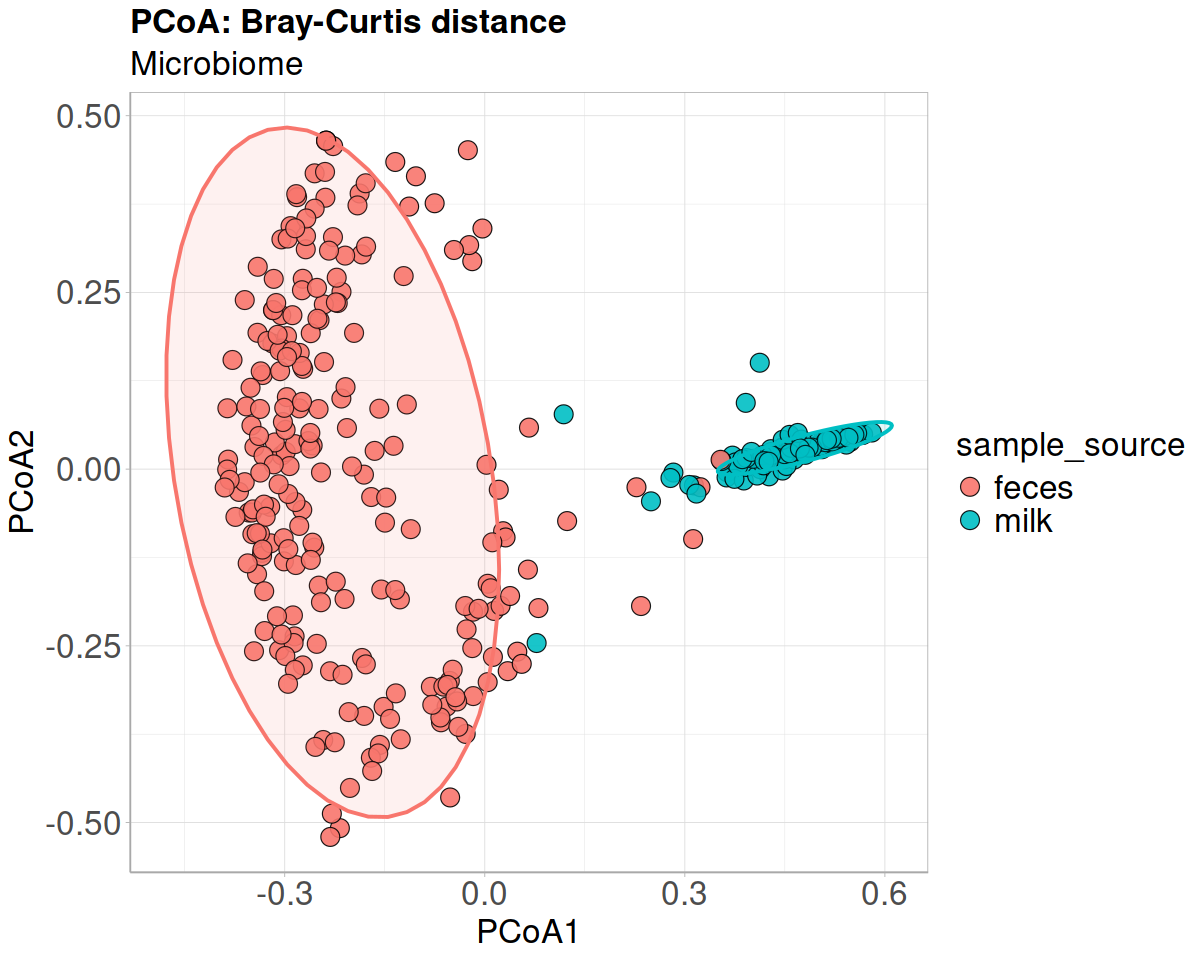

In [24]:
# Set plot dimensions
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

# Create PCoA plot for microbiome
pcoa_braycurtis_microbiome <- ggplot(data = pcoa_coordinates_microbiome, aes(x=PCoA1, y=PCoA2)) +
    # Plot sample points
    geom_point(aes(fill = sample_source), 
               size = 5, alpha=0.9, pch=21) +
    # Add confidence ellipses for each group
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    # Add titles
    labs(title = "PCoA: Bray-Curtis distance", 
         subtitle = "Microbiome") +
    # Customize theme
    custom_theme

pcoa_braycurtis_microbiome

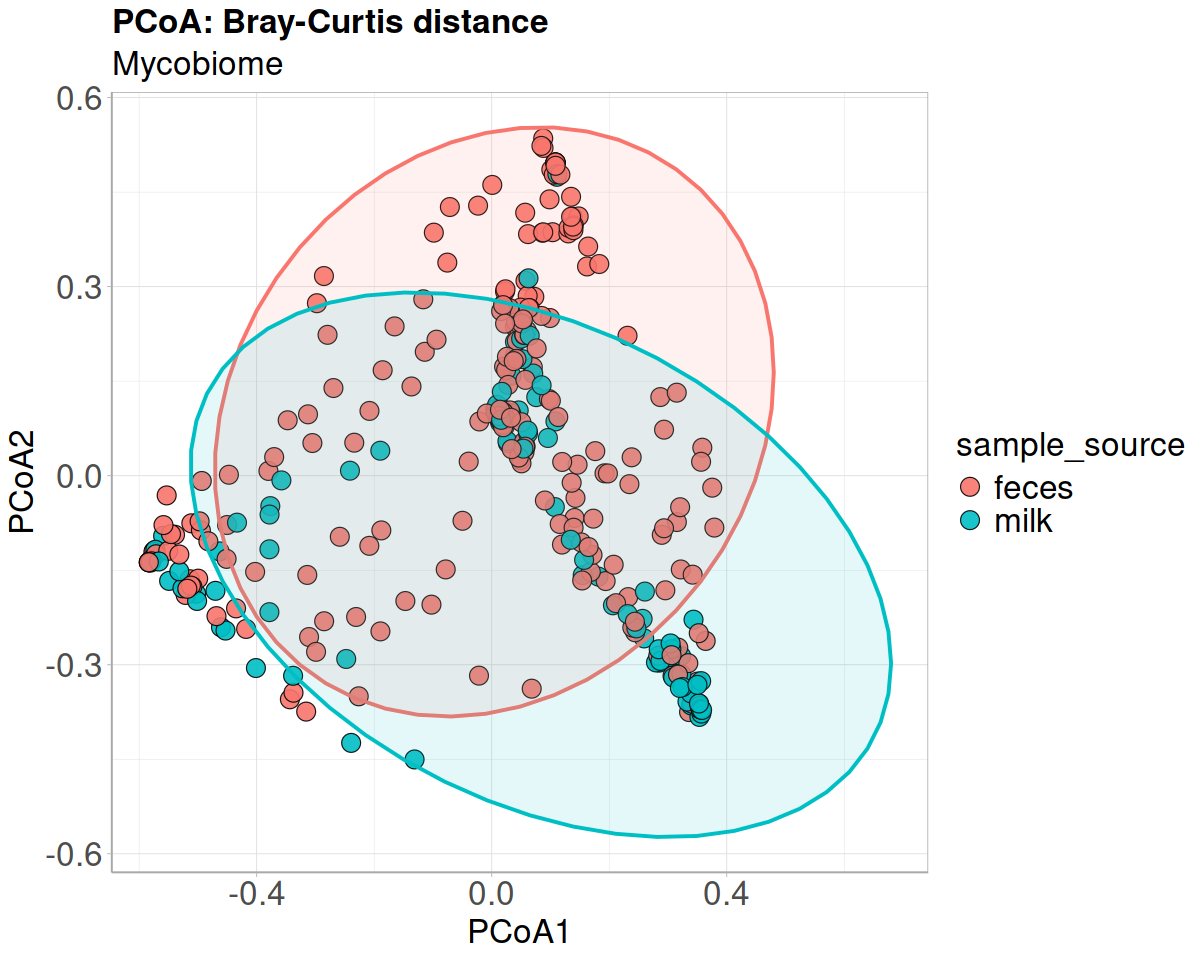

In [25]:
# Create PCoA plot for mycobiome
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_mycobiome <- ggplot(data = pcoa_coordinates_mycobiome, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill = sample_source), 
               size = 5, alpha=0.9, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    labs(title = "PCoA: Bray-Curtis distance", 
         subtitle = "Mycobiome") +
    custom_theme 

pcoa_braycurtis_mycobiome

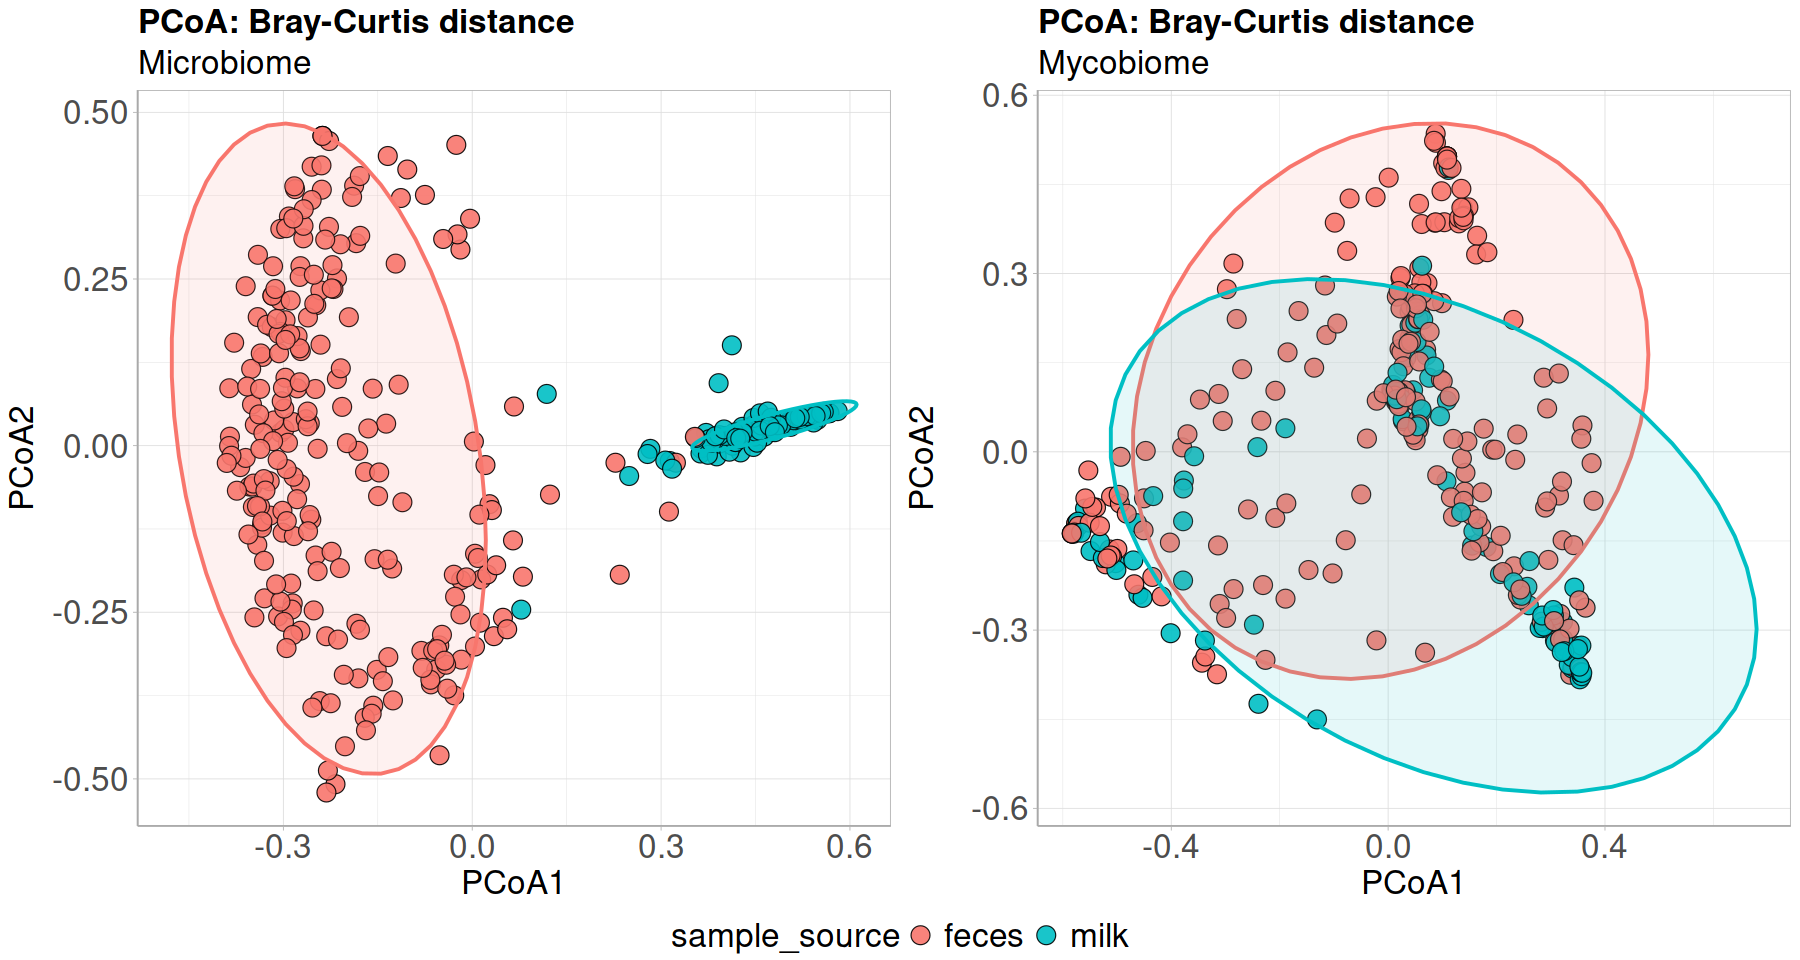

In [26]:
# Combine both plots side by side
width = 15
height = 8
options(repr.plot.width=width, repr.plot.height=height)

p <- ggarrange(pcoa_braycurtis_microbiome, pcoa_braycurtis_mycobiome,
          ncol = 2, nrow = 1, align = "hv", 
          common.legend = TRUE, legend = "bottom") 
print(p)

## PCoA Add-ons

### Loadings

Loadings show which taxa contribute most to the separation along each
axis.

In [27]:
# Function to compute loadings (correlation of taxa with PCoA axes)
# Credit source: https://github.com/cran/ape/blob/master/R/biplot.pcoa.R
compute_loadings <- function(x, Y) {
    plot.axes <- c(1, 2)
    pr.coo <- x$vectors
    n <- nrow(Y)
    points.stand <- scale(pr.coo[, plot.axes])
    S <- cov(Y, points.stand)
    U <- S %*% diag((x$values$Eigenvalues[plot.axes]/(n-1))^(-0.5))
    colnames(U) <- c('PCoA1', 'PCoA2')
    U <- data.frame(U)
    U['Length'] <- sqrt(U[['PCoA1']]^2 + U[['PCoA2']]^2)
    U <- U[order(-U[['Length']]), ]
    # Determine which quadrant each loading is in
    U['direction'] <- (U['PCoA1']/abs(U['PCoA1'])+1)/2 + (U['PCoA2']/abs(U['PCoA2'])+3)
    return(U)
}

In [28]:
# Compute loadings for microbiome
loadings_microbiome <- compute_loadings(pcoa_res_microbiome, otu_table(ps_microbiome))

# Select top 5 taxa with largest loadings
loadings_microbiome_selected <- loadings_microbiome[1:5, ]
loadings_microbiome_selected['names'] <- rownames(loadings_microbiome_selected)

# Select one representative loading per quadrant for clarity
loadings_microbiome_selected <- loadings_microbiome_selected[
    row.names(unique(loadings_microbiome_selected['direction'])), ]

In [29]:
# Compute loadings for mycobiome
loadings_mycobiome <- compute_loadings(pcoa_res_mycobiome, otu_table(ps_mycobiome))

loadings_mycobiome_selected <- loadings_mycobiome[1:5, ]
loadings_mycobiome_selected['names'] <- rownames(loadings_mycobiome_selected)
loadings_mycobiome_selected <- loadings_mycobiome_selected[
    row.names(unique(loadings_mycobiome_selected['direction'])), ]

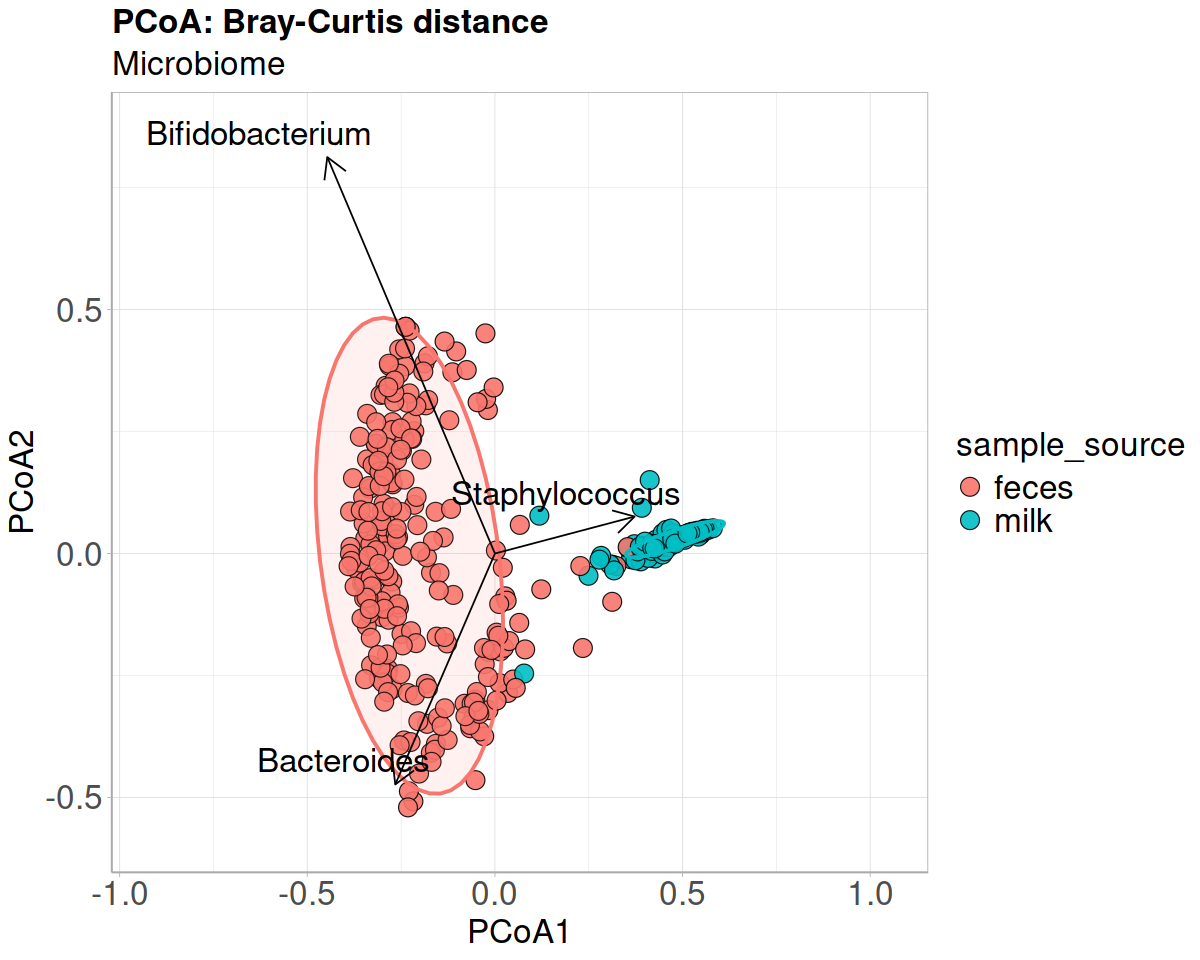

In [30]:
# Create enhanced PCoA plot with loadings for microbiome
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_microbiome <- ggplot(data = pcoa_coordinates_microbiome, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill = sample_source), 
               size = 5, alpha=0.9, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
################################### ADD-ON #####################################
# plot projected microbial genera
      geom_segment(data = loadings_microbiome_selected, 
                   aes(x = 0, y = 0, xend = PCoA1, yend = PCoA2), 
                   arrow = arrow(length = unit(0.03, "npc")), alpha = 1) + 
# plot names of the projected genera
      geom_text(data = loadings_microbiome_selected, 
                mapping = aes(x = PCoA1, y = PCoA2, label = names), 
                hjust = 0.8, vjust = -0.5, colour = "black", size = 7) +
# expand x and y limits to make plot better looking
      scale_x_continuous(expand = expansion(mult = 0.5)) +
      scale_y_continuous(expand = expansion(mult = 0.1)) +
################################################################################
    labs(title = "PCoA: Bray-Curtis distance", 
         subtitle = "Microbiome") +
    custom_theme 

pcoa_braycurtis_microbiome

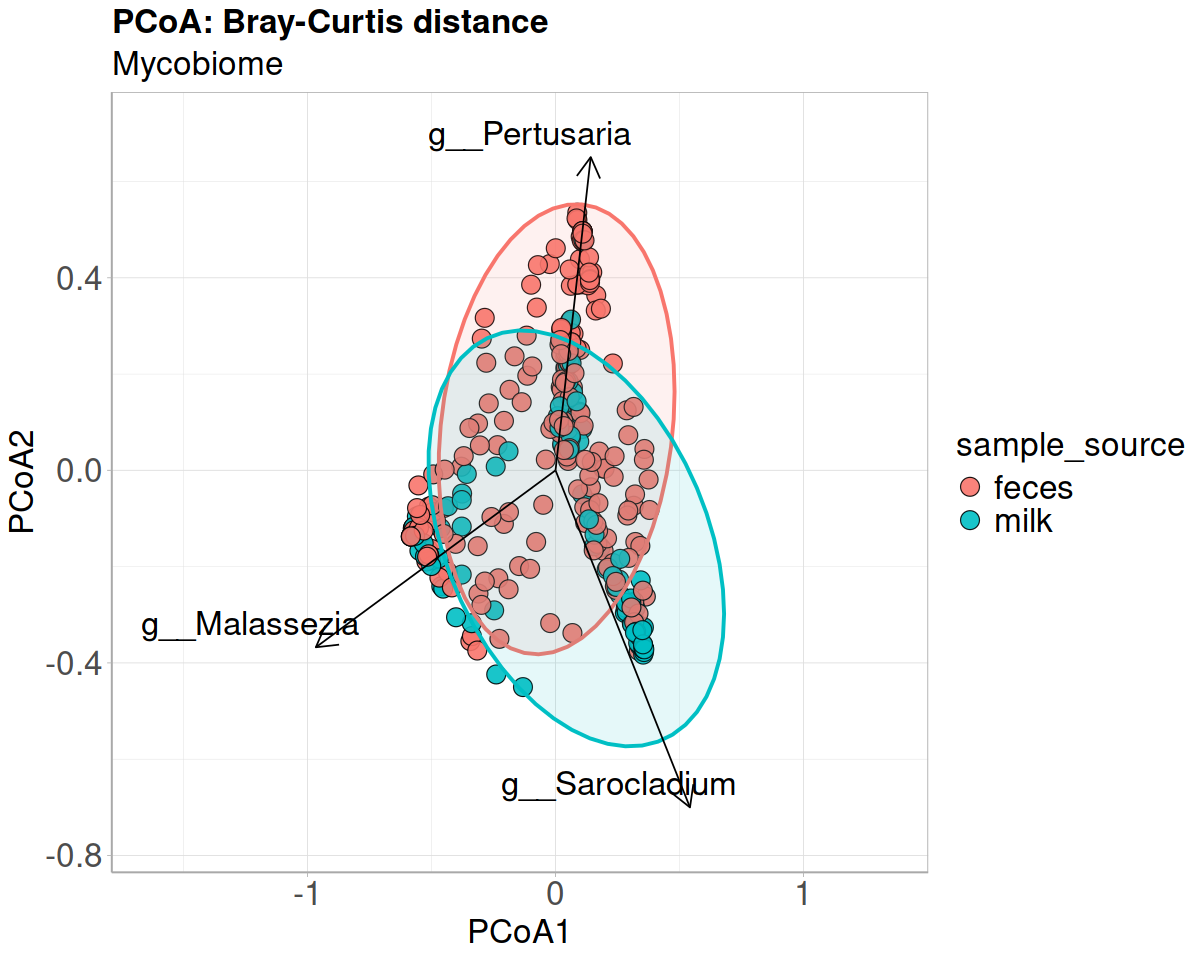

In [31]:
# Create enhanced PCoA plot with loadings for mycobiome
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_mycobiome <- ggplot(data = pcoa_coordinates_mycobiome, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill = sample_source), 
               size = 5, alpha=0.9, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
  ################################### ADD-ON #####################################
# plot projected mycobial genera
      geom_segment(data = loadings_mycobiome_selected, 
                   aes(x = 0, y = 0, xend = PCoA1, yend = PCoA2), 
                   arrow = arrow(length = unit(0.03, "npc")), alpha = 1) + 
# plot names of the projected genera
      geom_text(data = loadings_mycobiome_selected, 
                mapping = aes(x = PCoA1, y = PCoA2, label = names), 
                hjust = 0.8, vjust = -0.5, colour = "black", size = 7) +
# expand x and y limits to make plot better looking
      scale_x_continuous(expand = expansion(mult = 0.5)) +
      scale_y_continuous(expand = expansion(mult = 0.1)) +
################################################################################
    labs(title = "PCoA: Bray-Curtis distance", 
         subtitle = "Mycobiome") +
    custom_theme

pcoa_braycurtis_mycobiome

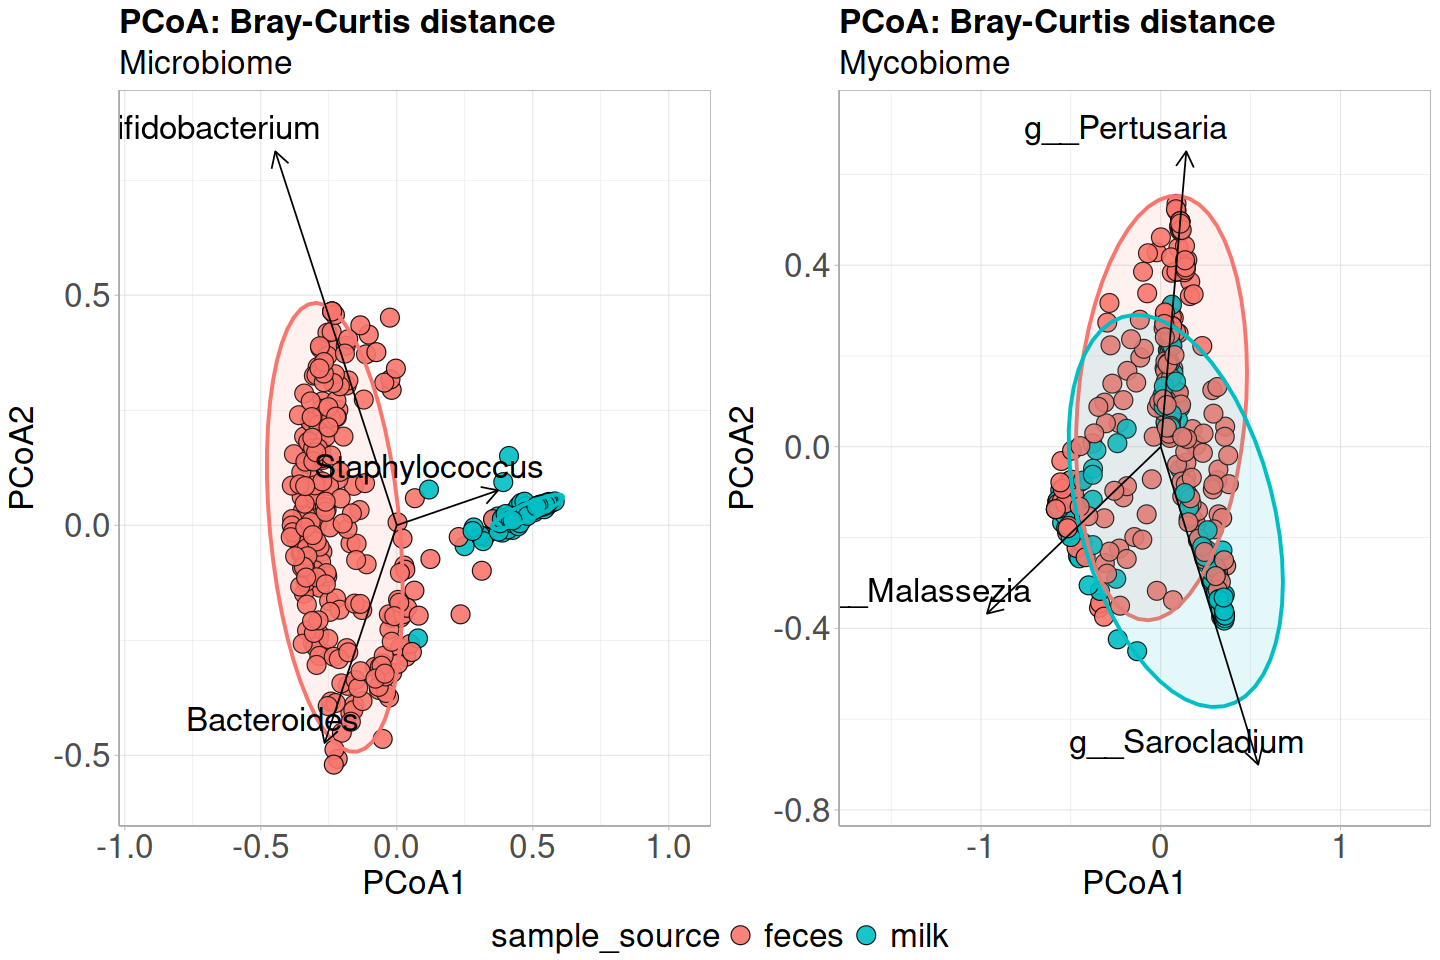

In [32]:
# Combine both enhanced plots
width = 12
height = 8
options(repr.plot.width=width, repr.plot.height=height)

p <- ggarrange(pcoa_braycurtis_microbiome, pcoa_braycurtis_mycobiome,
          ncol = 2, nrow = 1, align = "hv", 
          common.legend = TRUE, legend = "bottom") 
print(p)

### Statistical Testing with PERMANOVA

PERMANOVA tests whether group centroids differ significantly in
multivariate space.

In [33]:
# PERMANOVA test for microbiome
# Tests if sample source significantly affects community composition
set.seed(123)  # Set seed for reproducibility
permanova_microbiome <- adonis2(
    as.formula(paste0("bray_curtis_dist_microbiome ~ sample_source")), 
    data=data.frame(sample_data(ps_microbiome)), 
    permutations=9999)
permanova_microbiome

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample_source,1,31.78479,0.2984978,141.6956,1e-04
Residual,333,74.69769,0.7015022,NA,NA
Total,334,106.48248,1.0000000,NA,NA


In [34]:
# PERMANOVA test for mycobiome
set.seed(234)
permanova_mycobiome <- adonis2(
    as.formula(paste0("bray_curtis_dist_mycobiome ~ sample_source")), 
    data=data.frame(sample_data(ps_mycobiome)), 
    permutations=9999)
permanova_mycobiome

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample_source,1,3.767247,0.02902908,9.955688,1e-04
Residual,333,126.007676,0.97097092,NA,NA
Total,334,129.774922,1.00000000,NA,NA


### Explained Variance

In [35]:
# Calculate percentage of variance explained by each axis
explained_variance_microbiome <- pcoa_res_microbiome$values$Relative_eig * 100
explained_variance_mycobiome <- pcoa_res_mycobiome$values$Relative_eig * 100

### Updated Plots with Statistics

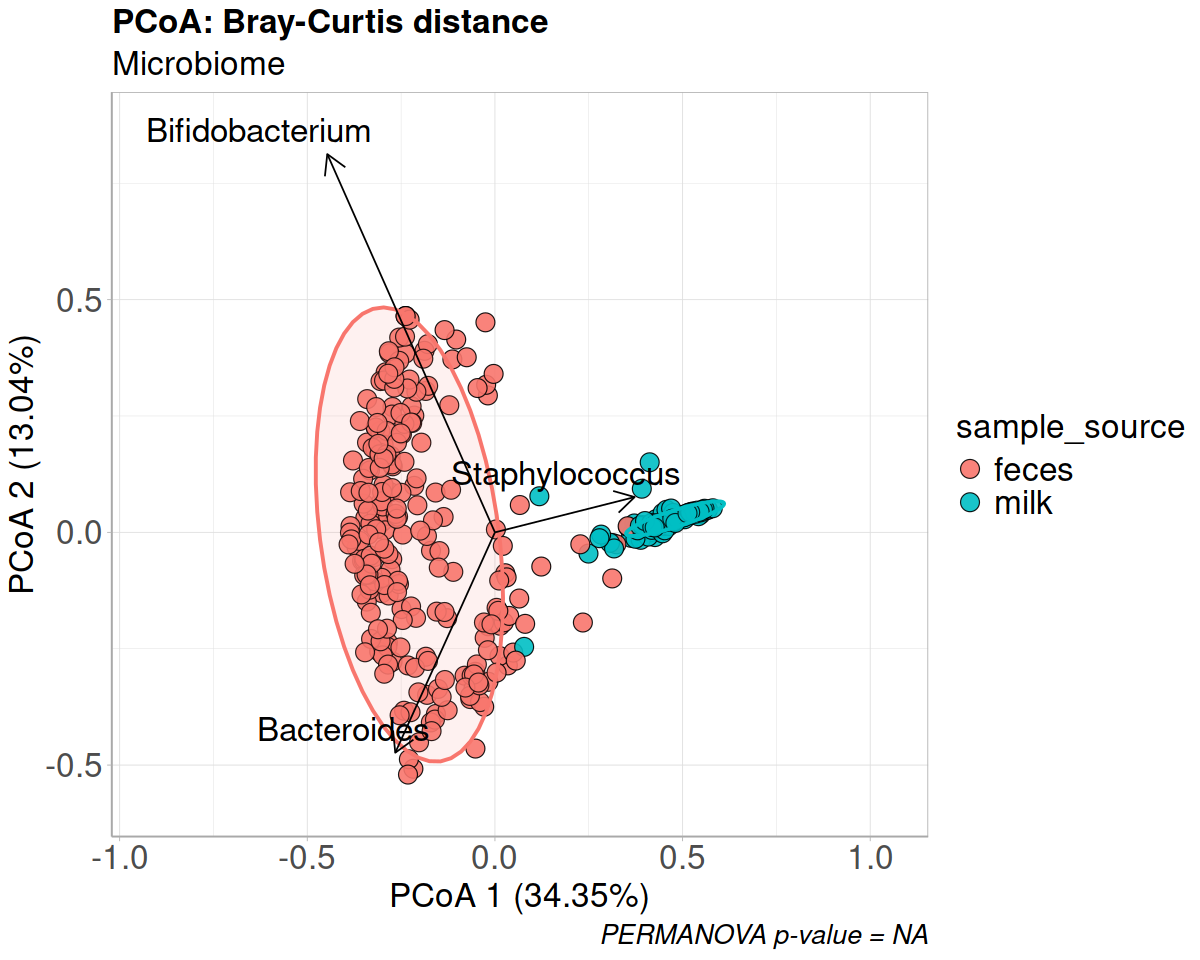

In [37]:
# Create final publication-ready plots with all annotations
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_microbiome <- ggplot(data = pcoa_coordinates_microbiome, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill = sample_source), 
               size = 5, alpha=0.9, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    geom_segment(data = loadings_microbiome_selected, 
                 aes(x = 0, y = 0, xend = PCoA1, yend = PCoA2), 
                 arrow = arrow(length = unit(0.03, "npc")), alpha = 1) + 
    geom_text(data = loadings_microbiome_selected, 
              mapping = aes(x = PCoA1, y = PCoA2, label = names), 
              hjust = 0.8, vjust = -0.5, colour = "black", size = 7) +
    scale_x_continuous(expand = expansion(mult = 0.5)) +
    scale_y_continuous(expand = expansion(mult = 0.1)) +
  ################################### ADD-ON #####################################
    # Add axis labels with explained variance
    labs(x = paste0("PCoA 1 (", sprintf('%.2f', explained_variance_microbiome[1]), "%)"), 
         y = paste0("PCoA 2 (", sprintf('%.2f', explained_variance_microbiome[2]), "%)"), 
         title = "PCoA: Bray-Curtis distance", 
         subtitle = "Microbiome",
         caption = paste0("PERMANOVA p-value = ", permanova_microbiome['Model', 'Pr(>F)'])) +
  ################################################################################
    custom_theme

pcoa_braycurtis_microbiome

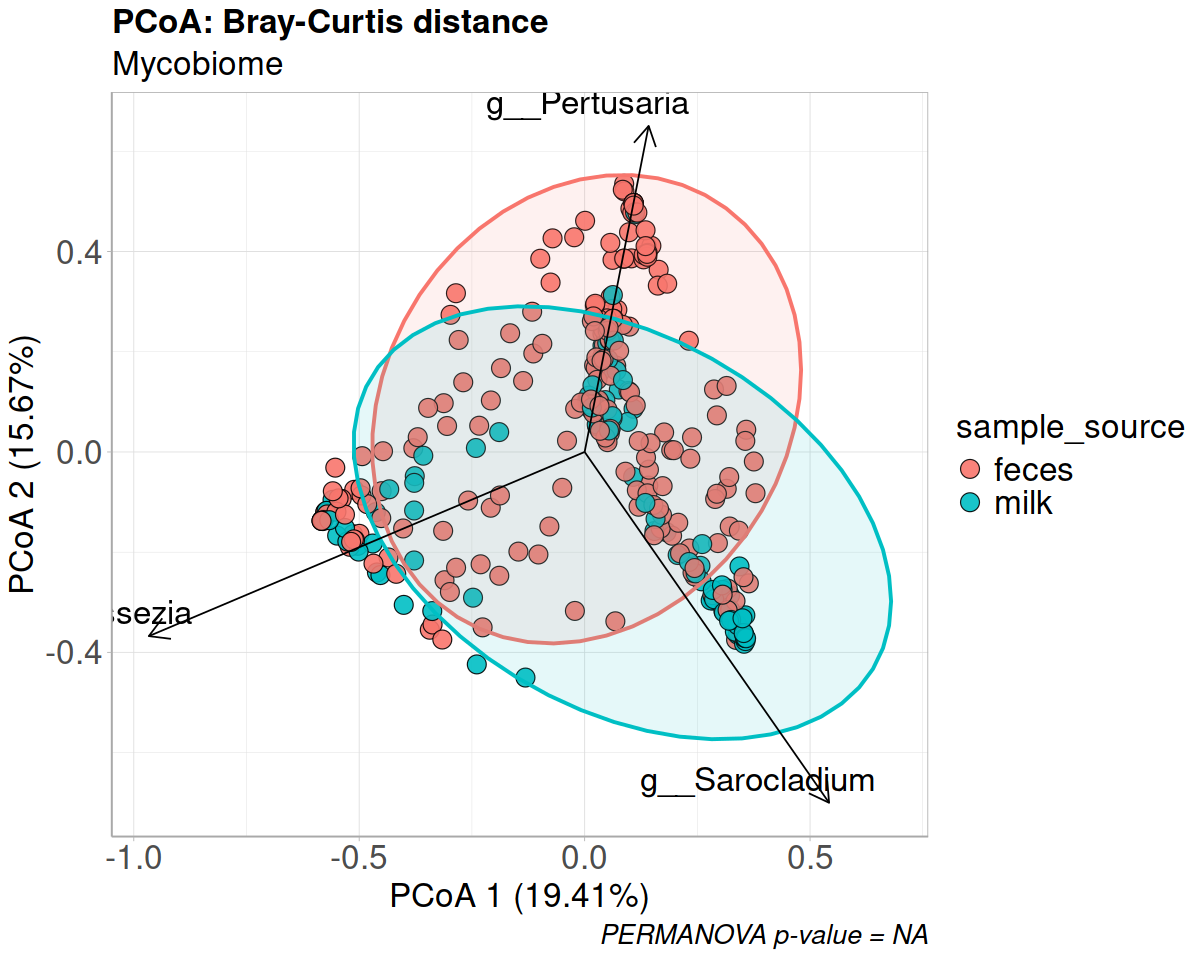

In [40]:
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_mycobiome <- ggplot(data = pcoa_coordinates_mycobiome, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill = sample_source), 
               size = 5, alpha=0.9, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
  # plot projected microbial genera
      geom_segment(data = loadings_mycobiome_selected, 
                   aes(x = 0, y = 0, xend = PCoA1, yend = PCoA2), 
                   arrow = arrow(length = unit(0.03, "npc")), alpha = 1) + 
# plot names of the projected genera
      geom_text(data = loadings_mycobiome_selected, 
                mapping = aes(x = PCoA1, y = PCoA2, label = names), 
                hjust = 0.8, vjust = -0.5, colour = "black", size = 7) +
################################### ADD-ON #####################################
# add titles
      labs(x = paste0("PCoA 1 (", sprintf('%.2f', explained_variance_mycobiome[1]), "%)"), 
           y = paste0("PCoA 2 (", sprintf('%.2f', explained_variance_mycobiome[2]), "%)"), 
           title = "PCoA: Bray-Curtis distance", 
           subtitle = "Mycobiome",
           caption = paste0("PERMANOVA p-value = ", permanova_mycobiome['Model', 'Pr(>F)']))+
################################################################################
    custom_theme 

pcoa_braycurtis_mycobiome

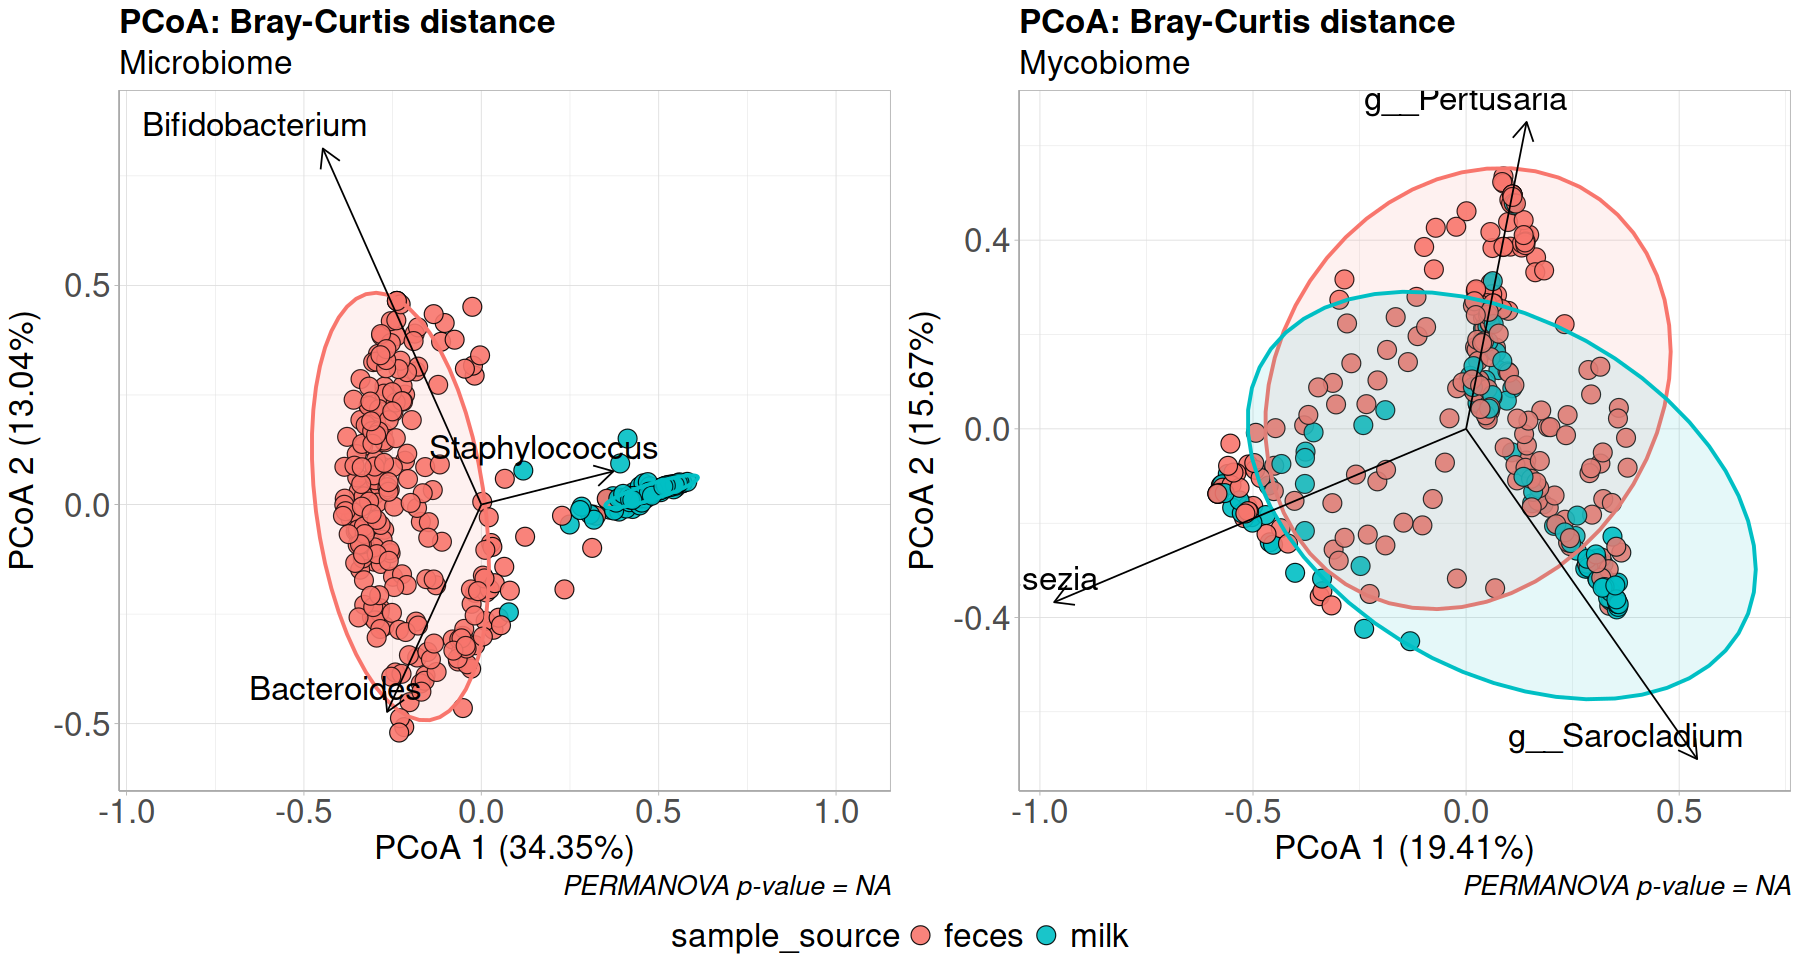

In [41]:
# Combine final plots
width = 15
height = 8
options(repr.plot.width=width, repr.plot.height=height)

p <- ggarrange(pcoa_braycurtis_microbiome, pcoa_braycurtis_mycobiome,
          ncol = 2, nrow = 1, align = "hv", 
          common.legend = TRUE, legend = "bottom") 
print(p)

# PCoA based on UniFrac Distances

UniFrac distances incorporate phylogenetic relationships between taxa.
This analysis requires phylogenetic trees (generated in file 2).

In [42]:
# Load phyloseq objects with phylogenetic trees
ps_microbiome_with_tree <- readRDS('../../data/data_analysis/ps_microbiome.with_tree.rds')
ps_mycobiome_with_tree  <- readRDS('../../data/data_analysis/ps_mycobiome.with_tree.rds')

ps_microbiome_with_tree
ps_mycobiome_with_tree

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 14691 taxa and 384 samples ]
sample_data() Sample Data:       [ 384 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 14691 taxa by 7 taxonomic ranks ]
phy_tree()    Phylogenetic Tree: [ 14691 tips and 14689 internal nodes ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 6159 taxa and 404 samples ]
sample_data() Sample Data:       [ 404 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 6159 taxa by 7 taxonomic ranks ]
phy_tree()    Phylogenetic Tree: [ 6159 tips and 6159 internal nodes ]

In [43]:
# Root the phylogenetic tree at midpoint for consistency
phy_tree(ps_microbiome_with_tree) <- midpoint.root(phy_tree(ps_microbiome_with_tree))
phy_tree(ps_mycobiome_with_tree) <- midpoint.root(phy_tree(ps_mycobiome_with_tree))

In [44]:
# Re-process data to ensure consistency
ps_microbiome_with_tree <- prune_samples(rowSums(otu_table(ps_microbiome_with_tree)) > 0, ps_microbiome_with_tree)
ps_mycobiome_with_tree <- prune_samples(rowSums(otu_table(ps_mycobiome_with_tree)) > 0, ps_mycobiome_with_tree)

# Convert to relative abundance
ps_microbiome_with_tree <- transform_sample_counts(ps_microbiome_with_tree, function(x) {x / sum(x)})
ps_mycobiome_with_tree <- transform_sample_counts(ps_mycobiome_with_tree, function(x) {x / sum(x)})

# Clean metadata
metadata_microbiome <- data.frame(sample_data(ps_microbiome_with_tree))
metadata_microbiome <- metadata_microbiome[, c('host.age', 
                                               'host.body.product', 
                                               'host.sex', 
                                               'host.subject.id')]
metadata_microbiome <- clean_metadata(metadata_microbiome)
sample_data(ps_microbiome_with_tree) <- metadata_microbiome
sample_names(ps_microbiome_with_tree) <- metadata_microbiome[['sample_id']]

metadata_mycobiome <- data.frame(sample_data(ps_mycobiome_with_tree))
metadata_mycobiome <- metadata_mycobiome[, c('host.age', 
                                             'host.body.product', 
                                             'host.sex', 
                                             'host.subject.id')]
metadata_mycobiome <- clean_metadata(metadata_mycobiome)
sample_data(ps_mycobiome_with_tree) <- metadata_mycobiome
sample_names(ps_mycobiome_with_tree) <- metadata_mycobiome[['sample_id']]

In [45]:
# Subset to common samples
sample_ids_microbiome <- metadata_microbiome[['sample_id']]
sample_ids_mycobiome <- metadata_mycobiome[['sample_id']]
sample_ids <- intersect(sample_ids_microbiome, sample_ids_mycobiome)

ps_microbiome_with_tree <- prune_samples(sample_ids, ps_microbiome_with_tree)
ps_mycobiome_with_tree <- prune_samples(sample_ids, ps_mycobiome_with_tree)

# Ensure same sample order
otu_table(ps_microbiome_with_tree) <- otu_table(ps_microbiome_with_tree)[sample_ids, ]
otu_table(ps_mycobiome_with_tree) <- otu_table(ps_mycobiome_with_tree)[sample_ids, ]

ps_microbiome_with_tree
ps_mycobiome_with_tree

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 14691 taxa and 343 samples ]
sample_data() Sample Data:       [ 343 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 14691 taxa by 7 taxonomic ranks ]
phy_tree()    Phylogenetic Tree: [ 14691 tips and 14690 internal nodes ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 6159 taxa and 343 samples ]
sample_data() Sample Data:       [ 343 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 6159 taxa by 7 taxonomic ranks ]
phy_tree()    Phylogenetic Tree: [ 6159 tips and 6158 internal nodes ]

In [46]:
# Calculate UniFrac distances
# alpha=0: unweighted, alpha=0.5: compromise, alpha=1: weighted
unifrac_microbiome <- GUniFrac(otu_table(ps_microbiome_with_tree), 
                               phy_tree(ps_microbiome_with_tree), 
                               alpha = c(0, 0.5, 1))$unifracs

unifrac_mycobiome <- GUniFrac(otu_table(ps_mycobiome_with_tree), 
                               phy_tree(ps_mycobiome_with_tree), 
                               alpha = c(0, 0.5, 1))$unifracs

saveRDS(unifrac_microbiome, "../../data/data_analysis/unifrac_microbiome.rds")
saveRDS(unifrac_mycobiome, "../../data/data_analysis/unifrac_mycobiome.rds")

Accumulate the abundance along the tree branches...
Compute pairwise distances ...
Completed!
Accumulate the abundance along the tree branches...
Compute pairwise distances ...
Completed!


In [47]:
unifrac_microbiome <- readRDS("../../data/data_analysis/unifrac_microbiome.rds")
unifrac_mycobiome <- readRDS("../../data/data_analysis/unifrac_mycobiome.rds")

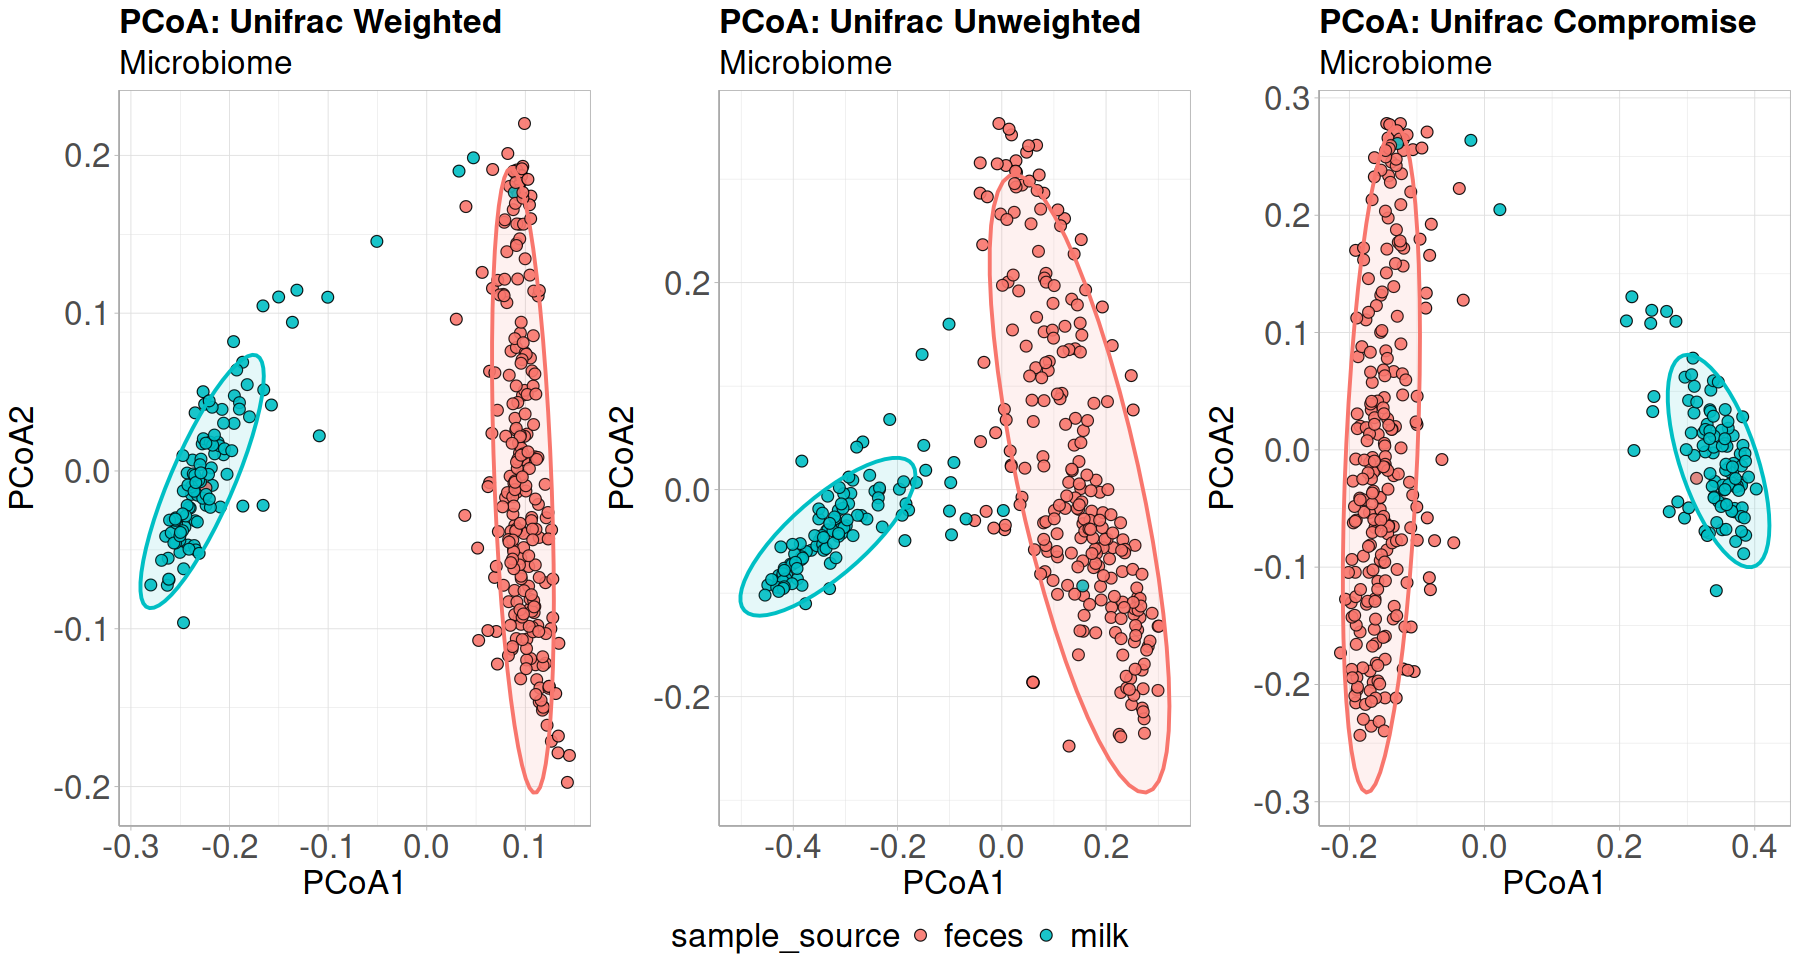

In [48]:
unifrac_types <- list(Weighted='d_1', Unweighted='d_UW', Compromise='d_0.5')
pcoa_plots <- lapply(names(unifrac_types), function(unifrac_type) {
    dist <- unifrac_microbiome[, , unifrac_types[[unifrac_type]]]
    # compute pcoa
    pcoa_res_microbiome <- pcoa(dist)

    # reformat the result table for plotting with ggplot
    pcoa_coordinates_microbiome <- data.frame(pcoa_res_microbiome$vectors)[, c('Axis.1', 'Axis.2')]
    colnames(pcoa_coordinates_microbiome) <- c('PCoA1', 'PCoA2')
    pcoa_coordinates_microbiome <- cbind(pcoa_coordinates_microbiome, sample_data(ps_microbiome_with_tree))
    pcoa_coordinates_microbiome$sample_type <- 'Microbiome' 
    
    
    p <- ggplot(data = pcoa_coordinates_microbiome, aes(x=PCoA1, y=PCoA2)) +
    # plot sample values projected on PCoA
          geom_point(aes(fill = sample_source), 
                     size = 3, alpha=0.9, pch=21) +
    # plot group circles
          stat_ellipse(geom = "polygon",
                       aes(color = sample_source, 
                           fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
    # add titles
          labs(
               title = paste0("PCoA: Unifrac ", unifrac_type), 
               subtitle = "Microbiome") +
    # custom plot design
          custom_theme
    return(p)
})

# combine figures together
width = 15
height = 8
options(repr.plot.width=width, repr.plot.height=height)
p_combined <- ggarrange(pcoa_plots[[1]], pcoa_plots[[2]], pcoa_plots[[3]],
          ncol = 3, nrow = 1, align = "hv", 
          common.legend = TRUE, legend = "bottom") 
print(p_combined)

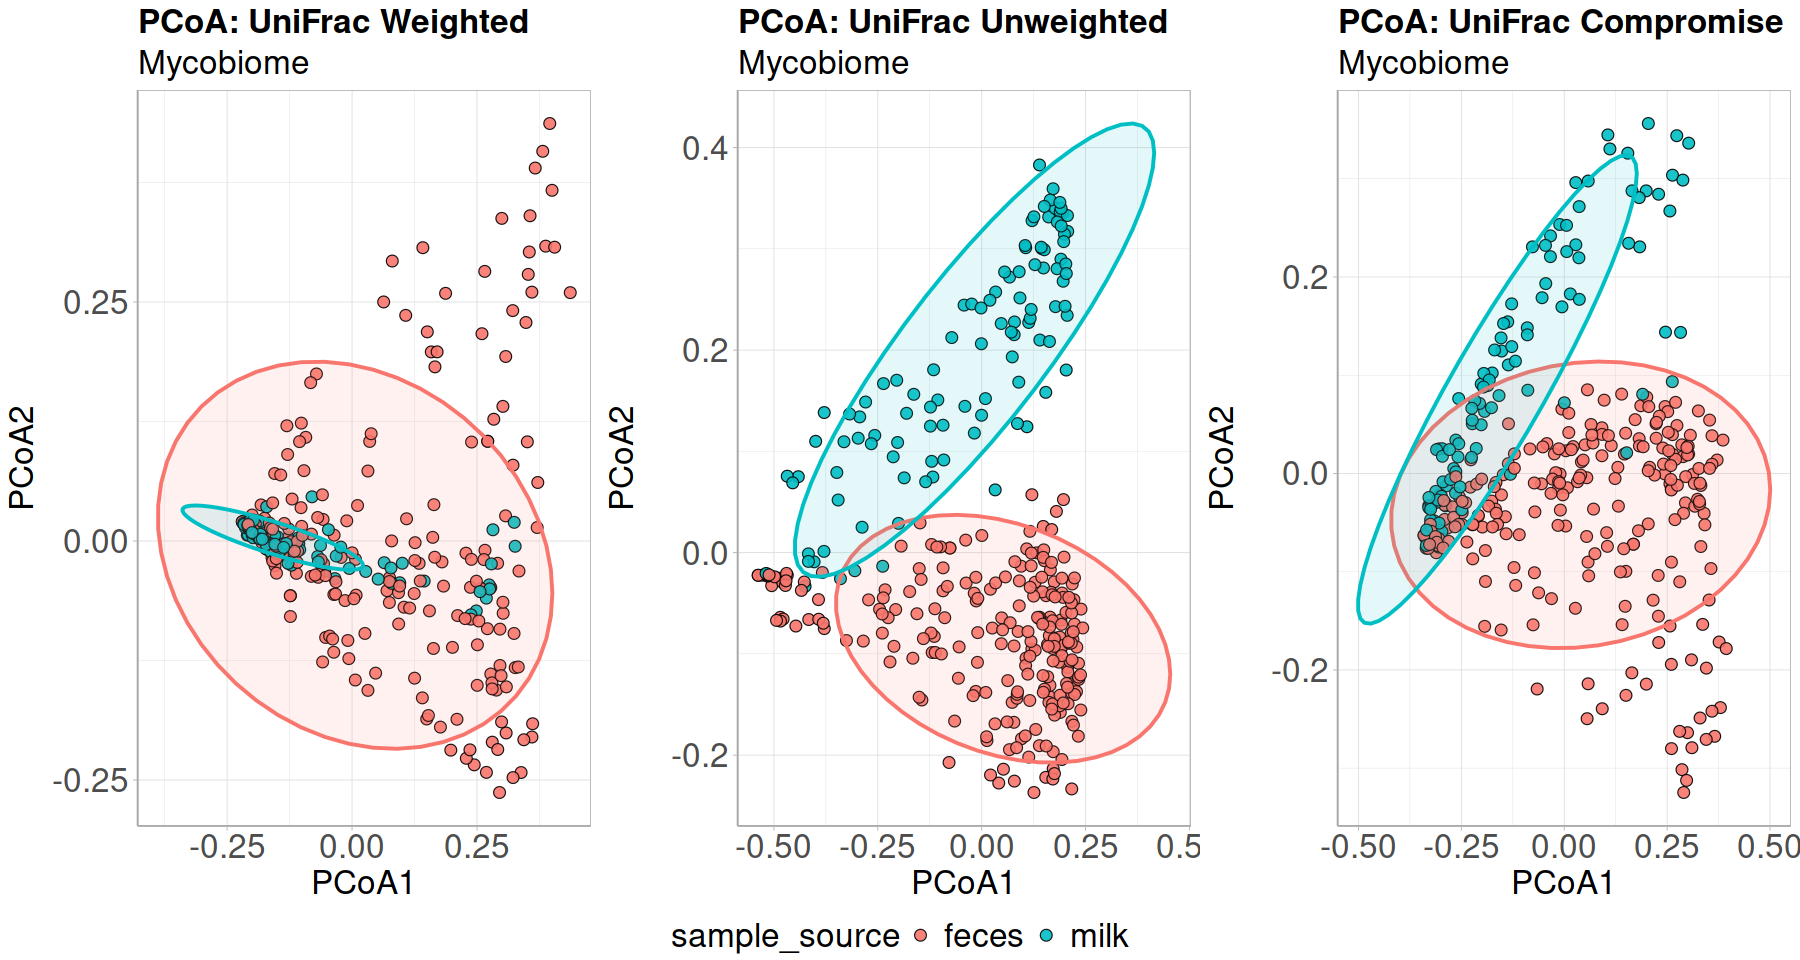

In [49]:
# Create PCoA plots for all three UniFrac variants
unifrac_types <- list(Weighted='d_1', Unweighted='d_UW', Compromise='d_0.5')

pcoa_plots <- lapply(names(unifrac_types), function(unifrac_type) {
    # Extract distance matrix for this UniFrac type
    dist <- unifrac_mycobiome[, , unifrac_types[[unifrac_type]]]
    
    # Perform PCoA
    pcoa_res_mycobiome <- pcoa(dist)

    # Extract coordinates
    pcoa_coordinates_mycobiome <- data.frame(pcoa_res_mycobiome$vectors)[, c('Axis.1', 'Axis.2')]
    colnames(pcoa_coordinates_mycobiome) <- c('PCoA1', 'PCoA2')
    pcoa_coordinates_mycobiome <- cbind(pcoa_coordinates_mycobiome, sample_data(ps_mycobiome_with_tree))
    pcoa_coordinates_mycobiome$sample_type <- 'Mycobiome' 
    
    # Create plot
    p <- ggplot(data = pcoa_coordinates_mycobiome, aes(x=PCoA1, y=PCoA2)) +
        geom_point(aes(fill = sample_source), 
                   size = 3, alpha=0.9, pch=21) +
        stat_ellipse(geom = "polygon",
                     aes(color = sample_source, 
                         fill = after_scale(alpha(colour, 0.1))), 
                     lwd=1.1, level=0.9, show.legend = FALSE) +
        labs(title = paste0("PCoA: UniFrac ", unifrac_type), 
             subtitle = "Mycobiome") +
        custom_theme
    return(p)
})

# Combine all three plots
width = 15
height = 8
options(repr.plot.width=width, repr.plot.height=height)

p_combined <- ggarrange(pcoa_plots[[1]], pcoa_plots[[2]], pcoa_plots[[3]],
          ncol = 3, nrow = 1, align = "hv", 
          common.legend = TRUE, legend = "bottom") 
print(p_combined)

# Procrustes Analysis for PCoA Unweighted UniFrac

**About Procrustes Analysis:** "Procrustes analysis is named after a
bandit from ancient Greek mythology that would hunt people down, and
adjust their sizes to his iron bed by either cutting their limbs off or
stretching them."

**Citation source:**
[https://medium.com/\@olga_kravchenko/generalized-procrustes-analysis-with-python-numpy-c571e8e8a421](https://medium.com/@olga_kravchenko/generalized-procrustes-analysis-with-python-numpy-c571e8e8a421){.uri}

**Figure source:**
<https://www.scielo.br/j/brag/a/w4DBp6nzxwvPFDR7JYWGWDr/?lang=en>

Procrustes analysis tests whether two ordinations have similar
structures by rotating, translating, and scaling one to match the other.

<img src="https://minio.scielo.br/documentstore/1678-4499/w4DBp6nzxwvPFDR7JYWGWDr/fe4b2ee3c20d0671acaeb9176a3a4705df41e0d7.jpg">

In [50]:
dist <- unifrac_microbiome[, , unifrac_types[['Unweighted']]]
# compute pcoa
pcoa_res_microbiome <- pcoa(dist)

# reformat the result table for plotting with ggplot
pcoa_unifrac_coordinates_microbiome <- data.frame(pcoa_res_microbiome$vectors)[, c('Axis.1', 'Axis.2')]
colnames(pcoa_unifrac_coordinates_microbiome) <- c('PCoA1', 'PCoA2')
pcoa_unifrac_coordinates_microbiome <- cbind(pcoa_unifrac_coordinates_microbiome, sample_data(ps_microbiome_with_tree))
pcoa_unifrac_coordinates_microbiome$sample_type <- 'Microbiome' 

In [51]:
dist <- unifrac_mycobiome[, , unifrac_types[['Unweighted']]]
# compute pcoa
pcoa_res_mycobiome <- pcoa(dist)

# reformat the result table for plotting with ggplot
pcoa_unhifrac_coordinates_mycobiome <- data.frame(pcoa_res_mycobiome$vectors)[, c('Axis.1', 'Axis.2')]
colnames(pcoa_unhifrac_coordinates_mycobiome) <- c('PCoA1', 'PCoA2')
pcoa_unhifrac_coordinates_mycobiome <- cbind(pcoa_unhifrac_coordinates_mycobiome, sample_data(ps_mycobiome_with_tree))
pcoa_unhifrac_coordinates_mycobiome$sample_type <- 'Mycobiome' 

In [52]:
# Combine microbiome and mycobiome coordinates for visualization
pcoa_coordinates <- rbind(pcoa_unifrac_coordinates_microbiome,
                          pcoa_unhifrac_coordinates_mycobiome)

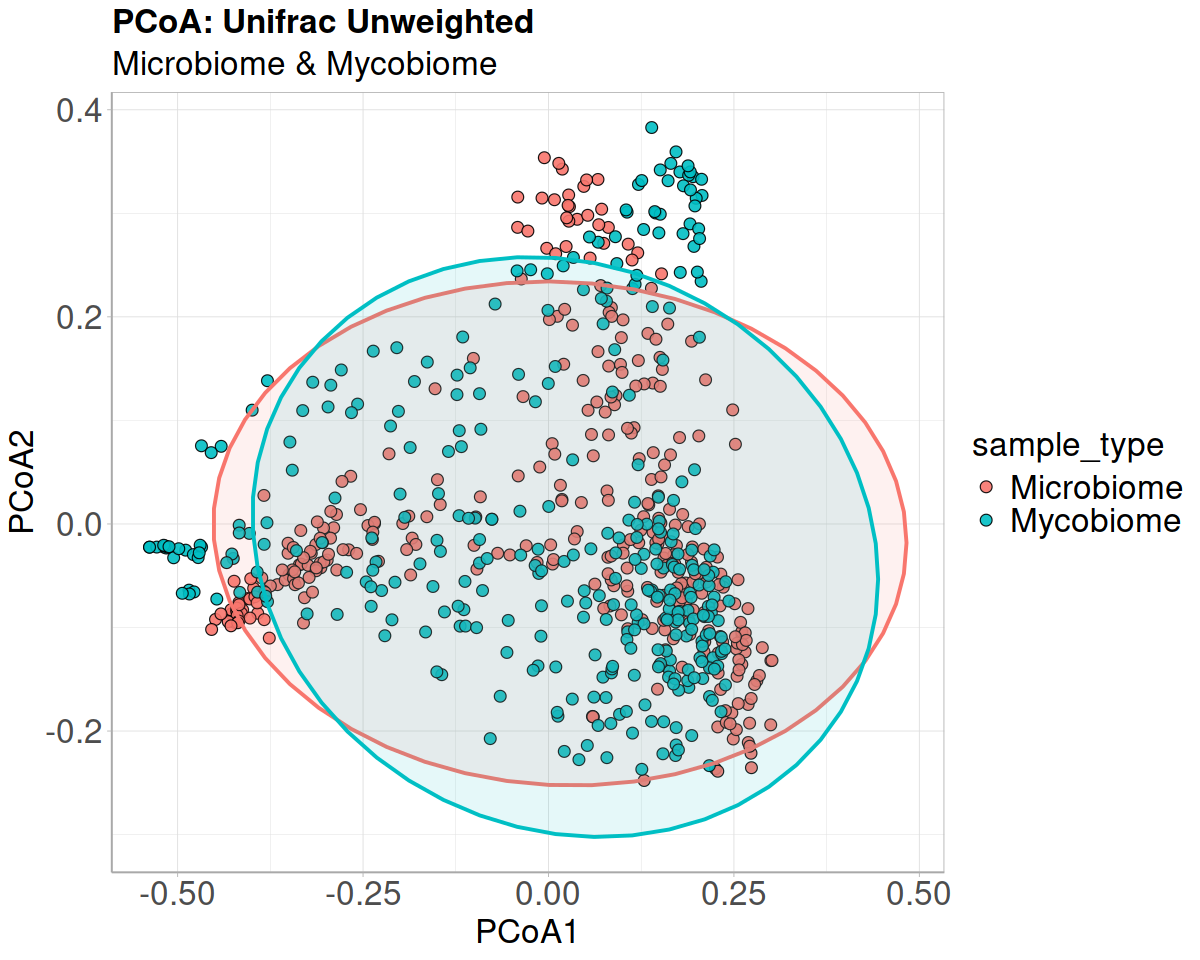

In [53]:
# Plot both datasets together before Procrustes transformation
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill=sample_type), 
               size = 3, alpha=0.9, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_type, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    labs(title = "PCoA: Unifrac Unweighted", 
         subtitle = "Microbiome & Mycobiome") +
    custom_theme 

pcoa_plot

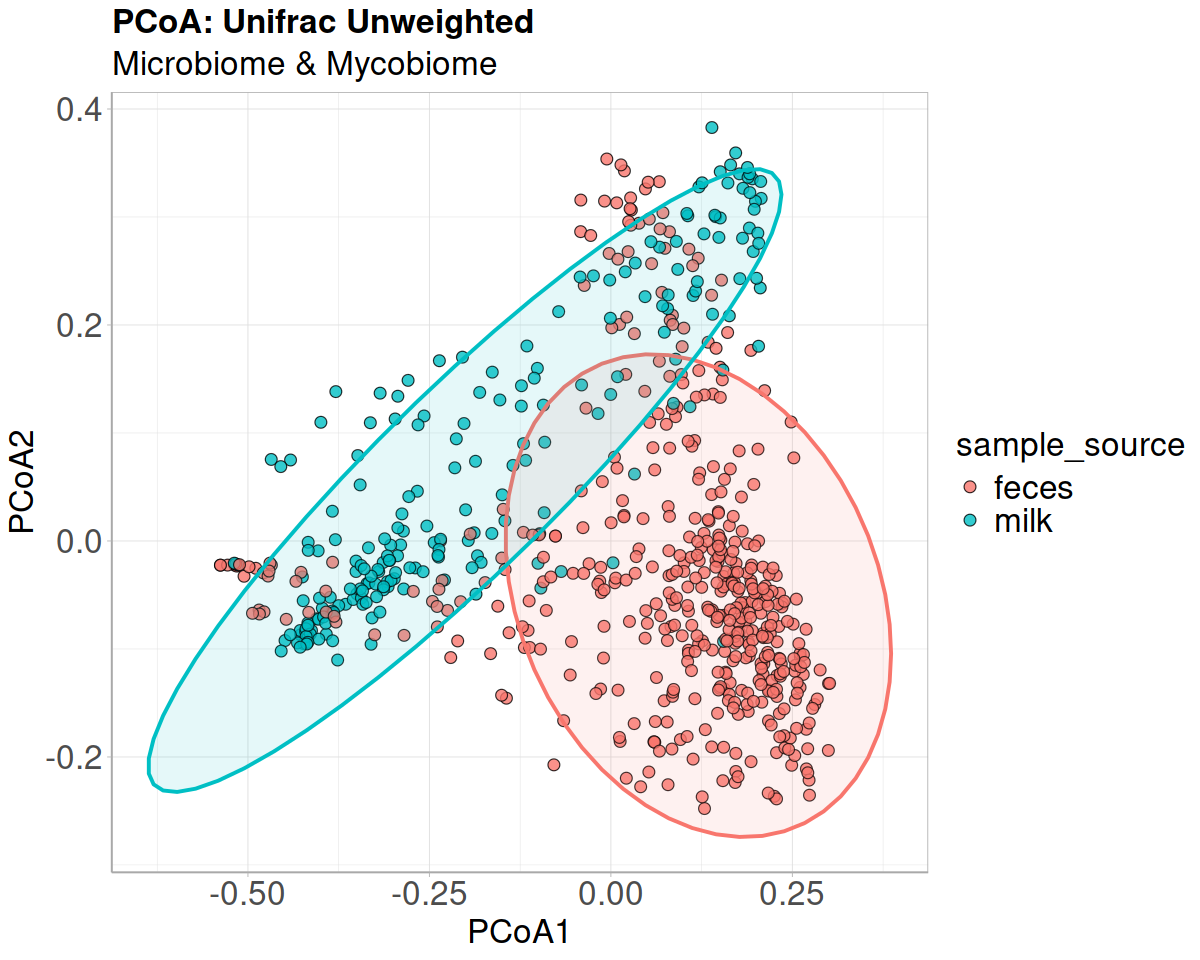

In [54]:
# Plot both datasets together before Procrustes transformation
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill=sample_source), 
               size = 3, alpha=0.8, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    labs(title = "PCoA: Unifrac Unweighted", 
         subtitle = "Microbiome & Mycobiome") +
    custom_theme

pcoa_plot

In [55]:
# Perform Procrustes transformation
# Use all available dimensions for more robust comparison
n <- min(ncol(pcoa_res_microbiome$vectors), ncol(pcoa_res_mycobiome$vectors))

procrustes_res <- procrustes(data.frame(pcoa_res_microbiome$vectors[, 1:n]), 
                             data.frame(pcoa_res_mycobiome$vectors[, 1:n]), 
                             scale=FALSE)

In [56]:
# Extract rotated coordinates for plotting
pcoa_rotated_mycobiome <- data.frame(procrustes_res$Yrot)
colnames(pcoa_rotated_mycobiome) <- paste0('PCoA', c(1:n))
pcoa_original_microbiome <- data.frame(procrustes_res$X)
colnames(pcoa_original_microbiome) <- paste0('PCoA', c(1:n))

pcoa_original_microbiome$sample_type <- 'Microbiome'
pcoa_rotated_mycobiome$sample_type <- 'Mycobiome'
pcoa_original_microbiome <- cbind(pcoa_original_microbiome, sample_data(ps_microbiome_with_tree))
pcoa_rotated_mycobiome <- cbind(pcoa_rotated_mycobiome, sample_data(ps_mycobiome_with_tree))

pcoa_coordinates_procrustes <- rbind(pcoa_original_microbiome, pcoa_rotated_mycobiome)

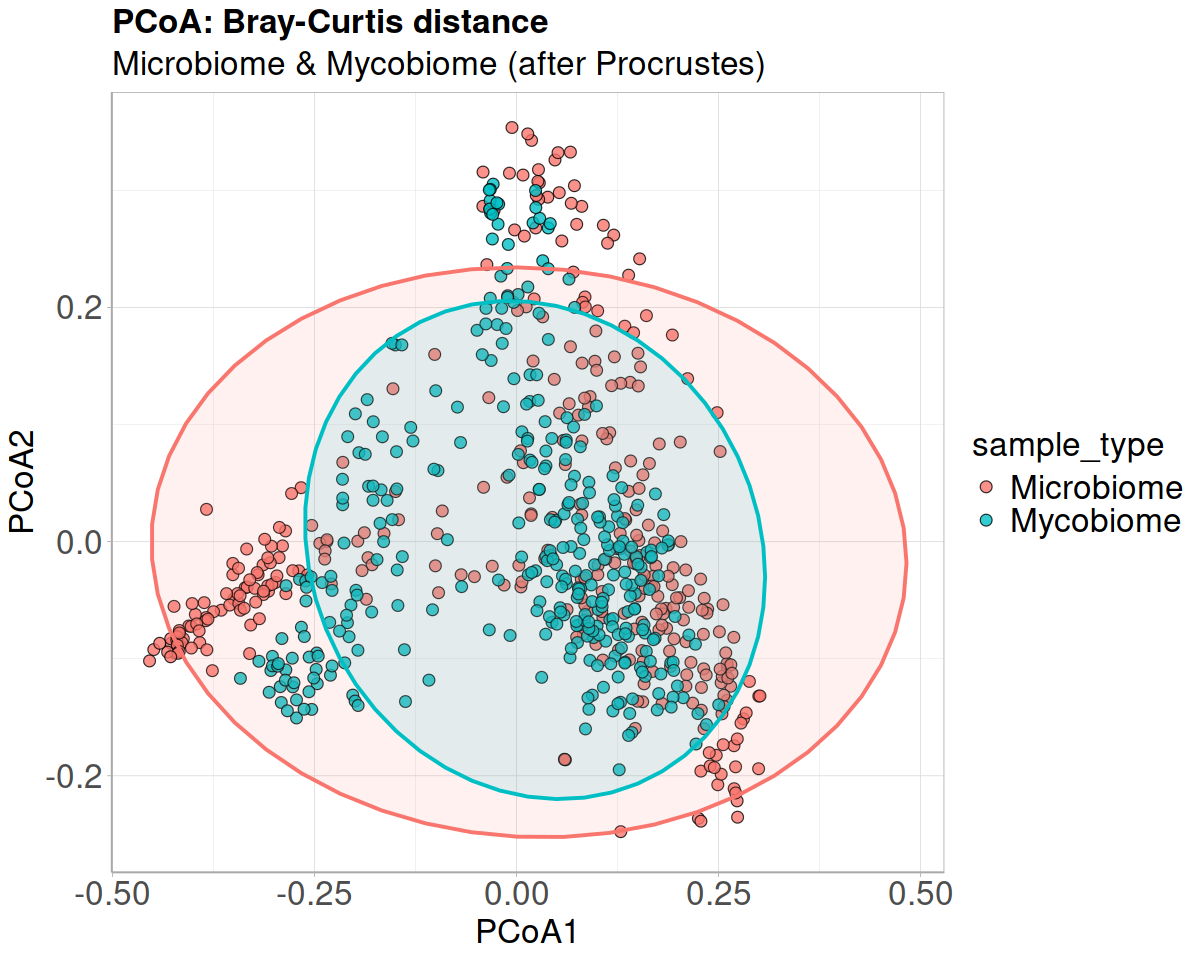

In [57]:
# Plot after Procrustes transformation
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates_procrustes, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill=sample_type), 
               size = 3, alpha=0.8, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_type, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    labs(title = "PCoA: Bray-Curtis distance", 
         subtitle = "Microbiome & Mycobiome (after Procrustes)") +
    custom_theme

pcoa_plot

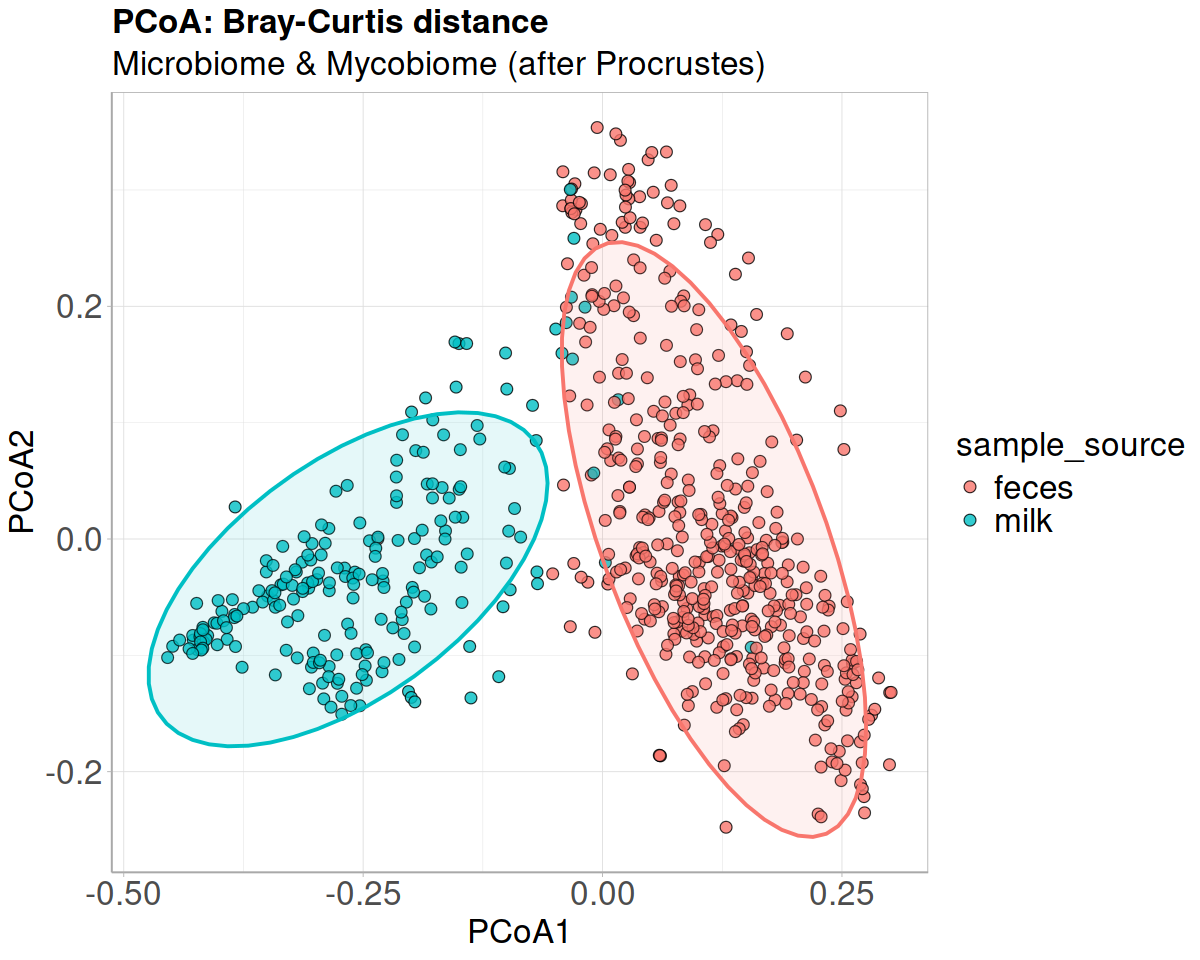

In [58]:
# Plot after Procrustes transformation
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates_procrustes, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill=sample_source), 
               size = 3, alpha=0.8, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_source, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    labs(title = "PCoA: Bray-Curtis distance", 
         subtitle = "Microbiome & Mycobiome (after Procrustes)") +
    custom_theme

pcoa_plot

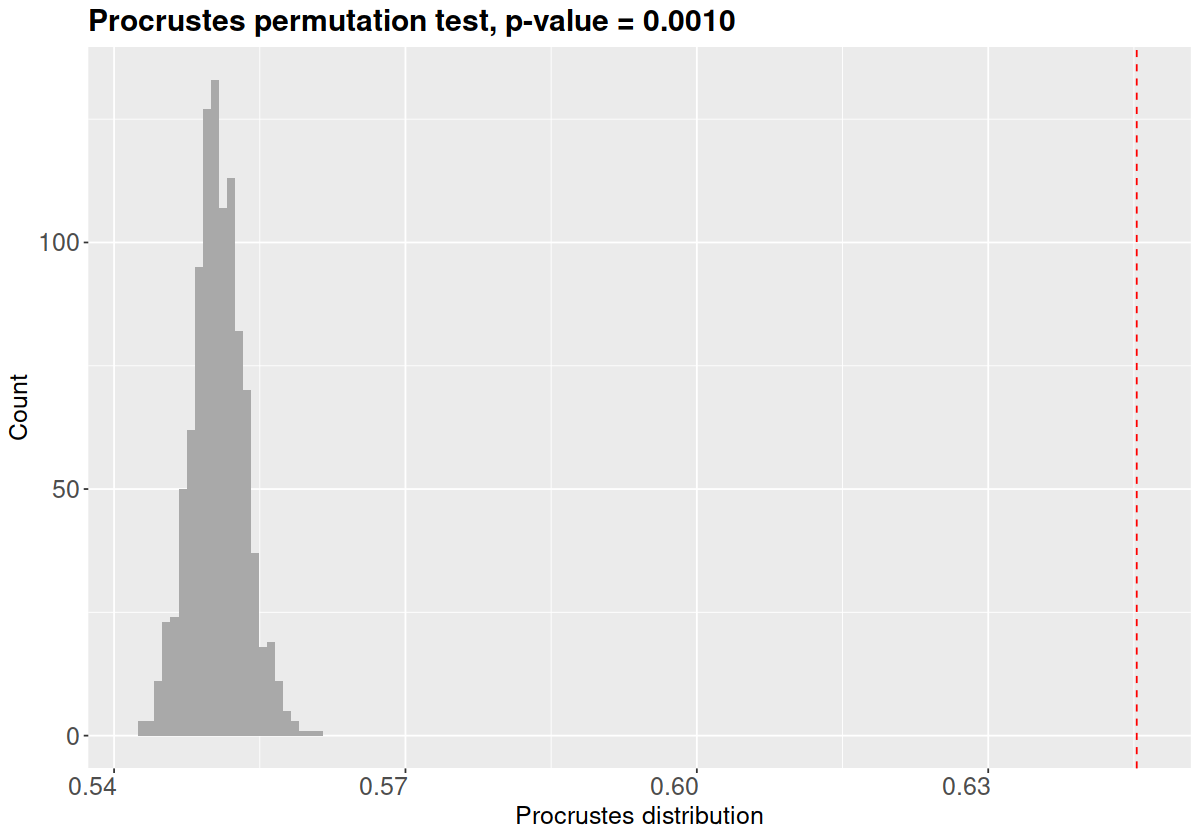

In [59]:
# Perform permutation test to assess significance
width = 10
height = 7
options(repr.plot.width=width, repr.plot.height=height)

n <- min(ncol(pcoa_res_microbiome$vectors), ncol(pcoa_res_mycobiome$vectors))

set.seed(123)  # For reproducibility
procrustes_permutation <- protest(data.frame(pcoa_res_microbiome$vectors[, 1:n]), 
                                  data.frame(pcoa_res_mycobiome$vectors[, 1:n]), 
                                  scale=FALSE, permutations = 999)

# Extract permutation distribution
procrustes_permutation_d <- data.frame(distances = procrustes_permutation$t)
procrustes_permutation_d0 <- procrustes_permutation$t0

# Plot permutation test results
procrustes_dist_plot <- ggplot(data = procrustes_permutation_d, aes(x = distances)) +
    geom_histogram(bins = 125, fill = "dark grey") +
    geom_vline(xintercept = procrustes_permutation_d0, lty = 2, color = "red") +
    labs(x = "Procrustes distribution", y = "Count") +
    theme(axis.text.x = element_text(hjust = 0.95, vjust=0.95),
          axis.text=element_text(size=15),
          axis.title=element_text(size=15),
          plot.title=element_text(size=18, face="bold")) + 
    theme(legend.position = "none") +
    ggtitle(paste0('Procrustes permutation test, p-value = ', 
                   sprintf('%.4f', procrustes_permutation$signif)))

procrustes_dist_plot

# Procrustes Analysis for PCoA Bray-Curtis

In [60]:
# Combine coordinates
pcoa_coordinates <- rbind(pcoa_coordinates_microbiome,
                          pcoa_coordinates_mycobiome)

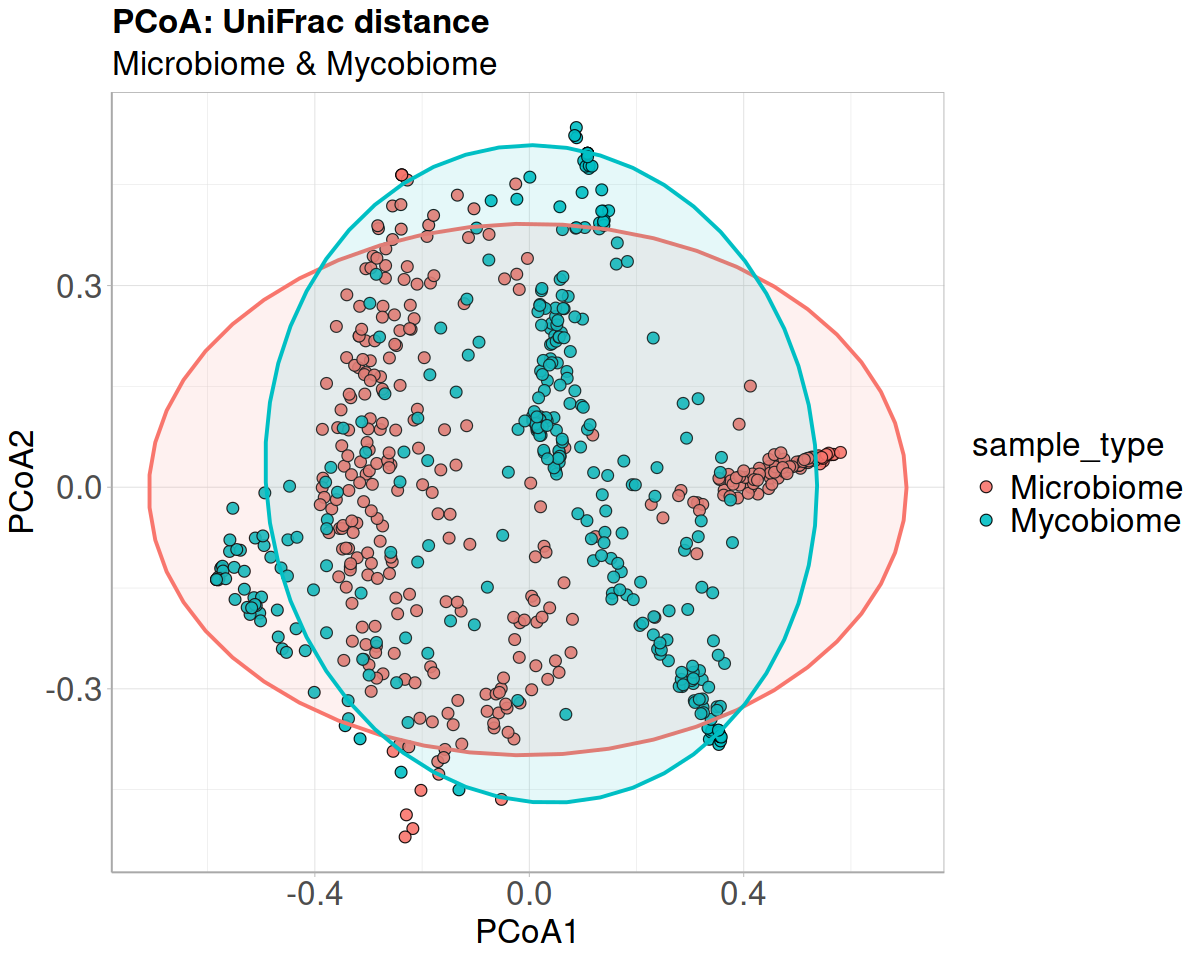

In [61]:
# Plot before Procrustes
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates, aes(x=PCoA1, y=PCoA2)) +
    geom_point(aes(fill=sample_type), 
               size = 3, alpha=0.9, pch=21) +
    stat_ellipse(geom = "polygon",
                 aes(color = sample_type, 
                     fill = after_scale(alpha(colour, 0.1))), 
                 lwd=1.1, level=0.9, show.legend = FALSE) +
    labs(title = "PCoA: UniFrac distance", 
         subtitle = "Microbiome & Mycobiome") +
    custom_theme

pcoa_plot

In [62]:
n <- min(ncol(pcoa_res_microbiome$vectors), ncol(pcoa_res_mycobiome$vectors))
# n <- 2

procrustes_res <- procrustes(data.frame(pcoa_res_microbiome$vectors[, 1:n]), 
                             data.frame(pcoa_res_mycobiome$vectors[, 1:n]), 
                            scale=FALSE)
pcoa_rotated_mycobiome <- data.frame(procrustes_res$Yrot)
colnames(pcoa_rotated_mycobiome) <- paste0('PCoA', c(1:n))
pcoa_original_microbiome <- data.frame(procrustes_res$X)
colnames(pcoa_original_microbiome) <- paste0('PCoA', c(1:n))
pcoa_original_microbiome$sample_type <- 'Microbiome'
pcoa_rotated_mycobiome$sample_type <- 'Mycobiome'
pcoa_coordinates_procrustes <- rbind(pcoa_original_microbiome, pcoa_rotated_mycobiome)

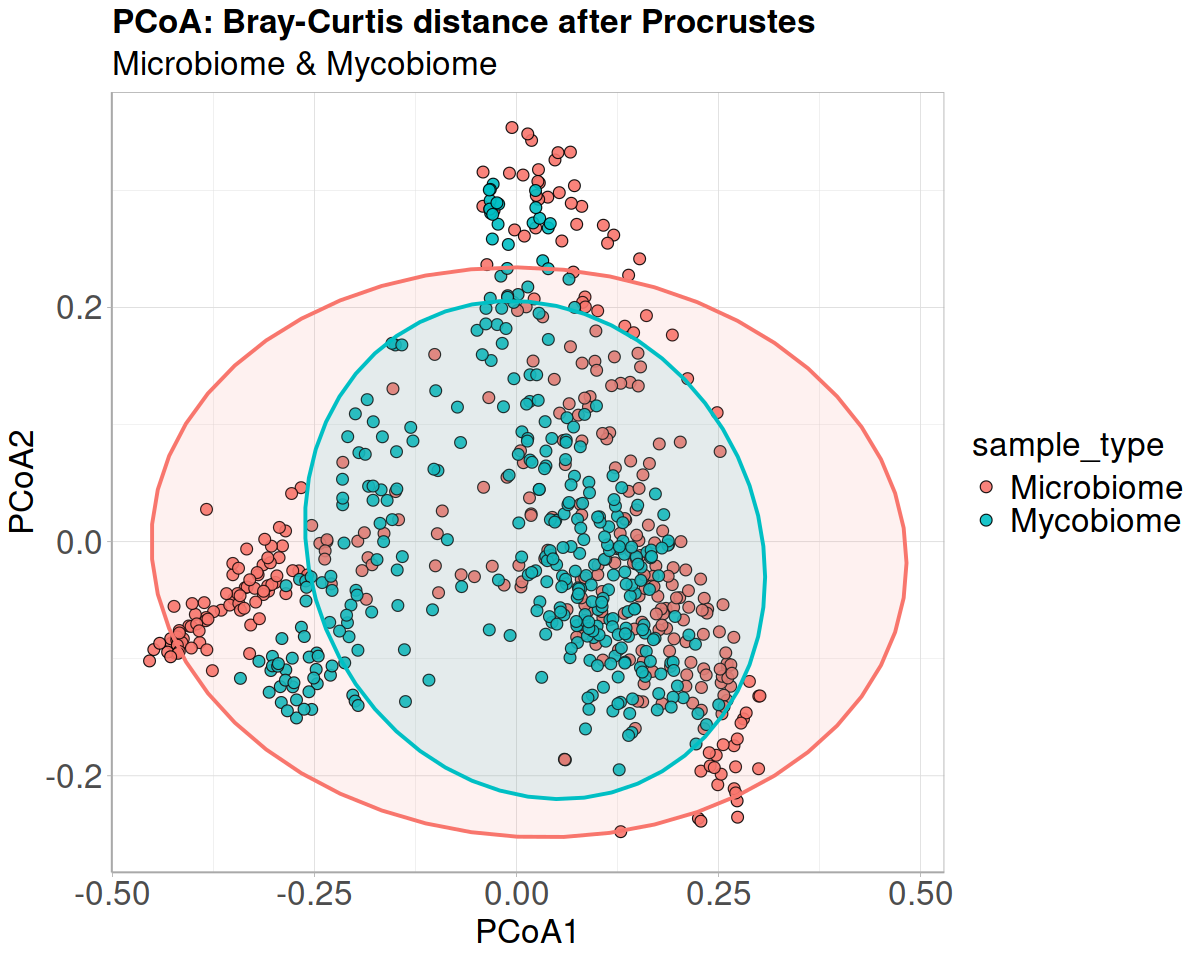

In [63]:
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates_procrustes, aes(x=PCoA1, y=PCoA2)) +
# plot sample values projected on PCoA
      geom_point(aes(fill=sample_type), 
                 size = 3, alpha=0.9, pch=21) +
# plot group circles
      stat_ellipse(geom = "polygon",
                   aes(color = sample_type, 
                       fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
# add titles
      labs(
           title = "PCoA: Bray-Curtis distance after Procrustes", 
           subtitle = "Microbiome & Mycobiome") +
# custom plot design
     custom_theme
pcoa_plot

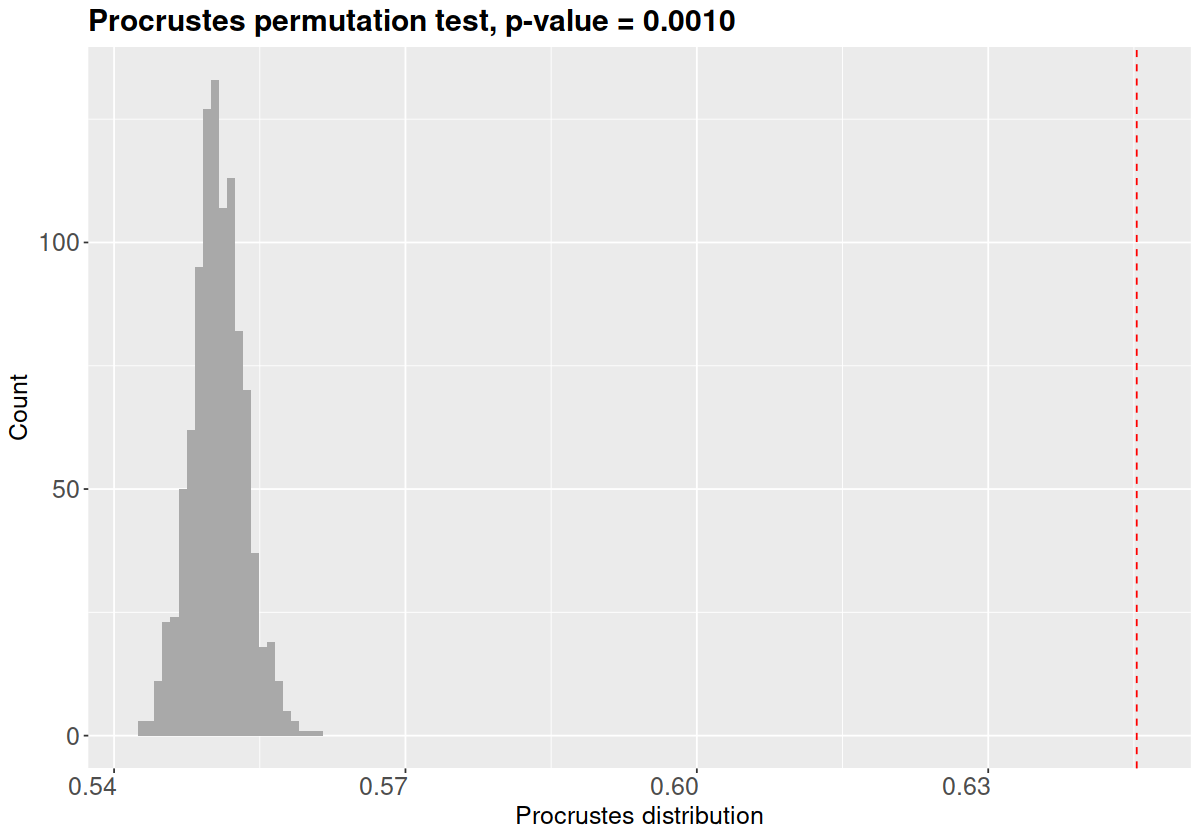

In [64]:
# Perform Procrustes permutation test
width = 10
height = 7
options(repr.plot.width=width, repr.plot.height=height)

n <- min(ncol(pcoa_res_microbiome$vectors), ncol(pcoa_res_mycobiome$vectors))

set.seed(123)
procrustes_permutation <- protest(data.frame(pcoa_res_microbiome$vectors[, 1:n]), 
                                  data.frame(pcoa_res_mycobiome$vectors[, 1:n]), 
                                  scale=FALSE, permutations = 999)

procrustes_permutation_d <- data.frame(distances = procrustes_permutation$t)
procrustes_permutation_d0 <- procrustes_permutation$t0

procrustes_dist_plot <- ggplot(data = procrustes_permutation_d, aes(x = distances)) +
    geom_histogram(bins = 125, fill = "dark grey") +
    geom_vline(xintercept = procrustes_permutation_d0, lty = 2, color = "red") +
    labs(x = "Procrustes distribution", y = "Count") +
    theme(axis.text.x = element_text(hjust = 0.95, vjust=0.95),
          axis.text=element_text(size=15),
          axis.title=element_text(size=15),
          plot.title=element_text(size=18, face="bold")) + 
    theme(legend.position = "none") +
    ggtitle(paste0('Procrustes permutation test, p-value = ', 
                   sprintf('%.4f', procrustes_permutation$signif)))

procrustes_dist_plot

# Canonical Correlation Analysis (CCA)

CCA identifies linear combinations of taxa from microbiome and mycobiome
that are maximally correlated with each other.

Reference:
<https://github.com/blekhmanlab/host_gene_microbiome_interactions/blob/main/Tutorial/README.md>

In [65]:
# Function to tune CCA penalty parameters using grid search
# Penalties control sparsity (feature selection)
tune_params_grid_search <- function(X, Y, 
                                    penaltyX=seq(0.1,0.3,length=5), 
                                    penaltyY=seq(0.1,0.3,length=5), 
                                    nfolds = NULL){
    num_samples <- nrow(X)
    if (is.null(nfolds)) {
      nfolds = num_samples
    }
    start_time <- Sys.time()
    
    # Create grid of parameter combinations
    params <- expand.grid(c(1:length(penaltyX)), c(1:length(penaltyY)))  
    set.seed(45)
    folds <- sample(rep_len(1:nfolds, num_samples))
    
    # Test each parameter combination using cross-validation
    corr_demo <- mclapply(c(1:dim(params)[1]), function(x){
        i <- params[x, 'Var1']
        j <- params[x, 'Var2']
        scoreXcv <- c()
        scoreYcv <- c()
        
        # Leave-one-out cross-validation
        score_cv <- lapply(c(1:nfolds), function(k){
            train_data_inds <- folds != k
            test_data_inds <- folds == k
            # Compute weights with sample k held out
            res <- CCA(X[train_data_inds,], Y[train_data_inds,], 
                      typex="standard", typez="standard",
                      penaltyx = penaltyX[i], penaltyz = penaltyY[j], 
                      K=1, niter = 12, trace = FALSE, standardize = TRUE)
            
            # Compute scores for held-out sample
            return(data.frame(k=k, 
                              scoreXcv=X[test_data_inds,]%*%res$u, 
                              scoreYcv=Y[test_data_inds,]%*%res$v))
        })
        score_cv <- do.call('rbind', score_cv)
        
        # Correlation between scores for X and Y
        return(cor(score_cv$scoreXcv, score_cv$scoreYcv))
    }, mc.cores=detectCores())
    
    corr_demo <- unlist(corr_demo)
    
    # Select parameters with best correlation
    best <- which.max(corr_demo)
    bestpenaltyX <- penaltyX[params[best, 'Var1']]
    bestpenaltyY <- penaltyY[params[best, 'Var2']]
    
    return(c(bestpenaltyX, bestpenaltyY))
}

In [66]:
# Function to run sparse CCA
run_sparseCCA <- function(X, Z, CCA.K, penaltyX, penaltyZ){
  CCA.out <-  CCA(X,Z,typex="standard",typez="standard",K=CCA.K,
                  penaltyx=penaltyX,penaltyz=penaltyZ)
  
  ## add rownames to output factors
  rownames(CCA.out$u) <- colnames(X)
  rownames(CCA.out$v) <- colnames(Z)
  ## compute contribution of selected features to each of the samples.
  CCA_var_genes <- X %*% CCA.out$u ## canonical variance for genes 
  CCA_var_microbes <- Z %*% CCA.out$v ## canonical variance for microbes
  
  return(list(CCA.out, CCA_var_genes, CCA_var_microbes))
}

In [67]:
# Function to test CCA significance using cross-validation
test_significance_LOOCV <- function(X, Y, K, penaltyX, penaltyY){
    num_samples <- nrow(X)
    corr_pval <- c()
    
    for (j in c(1:K)){
        scoreXcv <- c()
        scoreYcv <- c()
        
        # Leave-one-out cross-validation
        for (k in c(1:num_samples)){
            res <- CCA(X[-k,], Y[-k,], 
                      typex="standard", typez="standard",
                      penaltyx = penaltyX, penaltyz = penaltyY, 
                      K=K, niter = 12, trace = FALSE, standardize = TRUE)
            
            scoreXcv[k] <- X[k,] %*% res$u[,j]
            scoreYcv[k] <- Y[k,] %*% res$v[,j]
        }
        
        # Test correlation significance
        corr <- cor.test(scoreXcv, scoreYcv)
        corr_pval[j] <- corr$p.value
    }
    return(corr_pval)
}

In [68]:
# Filter out rarely present taxa (present in <1% of samples)
otu_microbiome <- data.frame(otu_table(ps_microbiome))
otu_mycobiome <- data.frame(otu_table(ps_mycobiome))

otu_microbiome <- otu_microbiome[, colSums(otu_microbiome != 0)/nrow(otu_microbiome) > 0.01]
otu_mycobiome <- otu_mycobiome[, colSums(otu_mycobiome != 0)/nrow(otu_mycobiome) > 0.01]

otu_microbiome <- clr(otu_microbiome)
otu_mycobiome <- clr(otu_mycobiome)

dim(otu_microbiome)
dim(otu_mycobiome)

[1] 335 200

[1] 335  37

In [69]:
# Find optimal penalty parameters
bestPenalty <- tune_params_grid_search(as.matrix(otu_microbiome), 
                                       as.matrix(otu_mycobiome), 
                                       nfolds=10)
bestpenaltyX <- bestPenalty[1]
bestpenaltyY <- bestPenalty[2]

In [70]:
# Run CCA with optimal parameters
cca.k = 10  # Number of canonical components to extract
cca_results <- run_sparseCCA(as.matrix(otu_microbiome), 
                             as.matrix(otu_mycobiome), 
                             cca.k, 
                             bestpenaltyX, bestpenaltyY)

123456789101112131415
12345678910111213
1234567
123456789
12345678910
123456789101112131415
123456789101112
123456789101112131415
123456789101112131415
123456789101112131415


In [ ]:
# Test significance of each component
CCA_pval <- test_significance_LOOCV(as.matrix(otu_microbiome), 
                                   as.matrix(otu_mycobiome),
                                   cca.k, 
                                   bestpenaltyX, bestpenaltyY)

# Adjust for multiple testing
CCA_padj <- p.adjust(CCA_pval, method = "BH")
saveRDS(CCA_padj, '../../data/data_analysis/CCA_padj.rds')

In [71]:
CCA_padj <- readRDS('../../data/data_analysis/CCA_padj.rds')

In [72]:
# Prepare data for visualization
# Extract microbiome component scores
components_microbiome <- as.data.frame(cca_results[[2]])
colnames(components_microbiome) <- sprintf("Comp%02d", 1:cca.k)
components_microbiome$sample <- rownames(components_microbiome)
components_microbiome <- pivot_longer(components_microbiome, 
                                     cols = !sample, 
                                     names_to = "component", 
                                     values_to = "Microbiome")

# Extract mycobiome component scores
components_mycobiome <- as.data.frame(cca_results[[3]])
colnames(components_mycobiome) <- sprintf("Comp%02d", 1:cca.k)
components_mycobiome$sample <- rownames(components_mycobiome)
components_mycobiome <- pivot_longer(components_mycobiome, 
                                     cols = !sample, 
                                     names_to = "component", 
                                     values_to = "Mycobiome")

# Combine into single dataframe
df_comp <- cbind(components_microbiome, components_mycobiome$Mycobiome)
df_comp <- as.data.frame(df_comp)
colnames(df_comp) <- c("sample", "component", "Microbiome", "Mycobiome")

In [73]:
# Extract feature coefficients (taxa loadings)
# Microbiome coefficients
coefficients_microbiome <- data.frame(cca_results[[1]]$u)
colnames(coefficients_microbiome) <- sprintf("Comp%02d", 1:cca.k)
coefficients_microbiome$taxa <- row.names(coefficients_microbiome)
coefficients_microbiome <- pivot_longer(coefficients_microbiome, 
                                       cols = !taxa, 
                                       names_to = "component", 
                                       values_to = "coefficient")
# Keep only non-zero coefficients (sparse CCA sets many to zero)
coefficients_microbiome <- coefficients_microbiome[coefficients_microbiome$coefficient != 0, ]

# Mycobiome coefficients
coefficients_mycobiome <- data.frame(cca_results[[1]]$v)
colnames(coefficients_mycobiome) <- sprintf("Comp%02d", 1:cca.k)
coefficients_mycobiome$taxa <- row.names(coefficients_mycobiome)
coefficients_mycobiome <- pivot_longer(coefficients_mycobiome, 
                                      cols = !taxa, 
                                      names_to = "component", 
                                      values_to = "coefficient")
coefficients_mycobiome <- coefficients_mycobiome[coefficients_mycobiome$coefficient != 0, ]

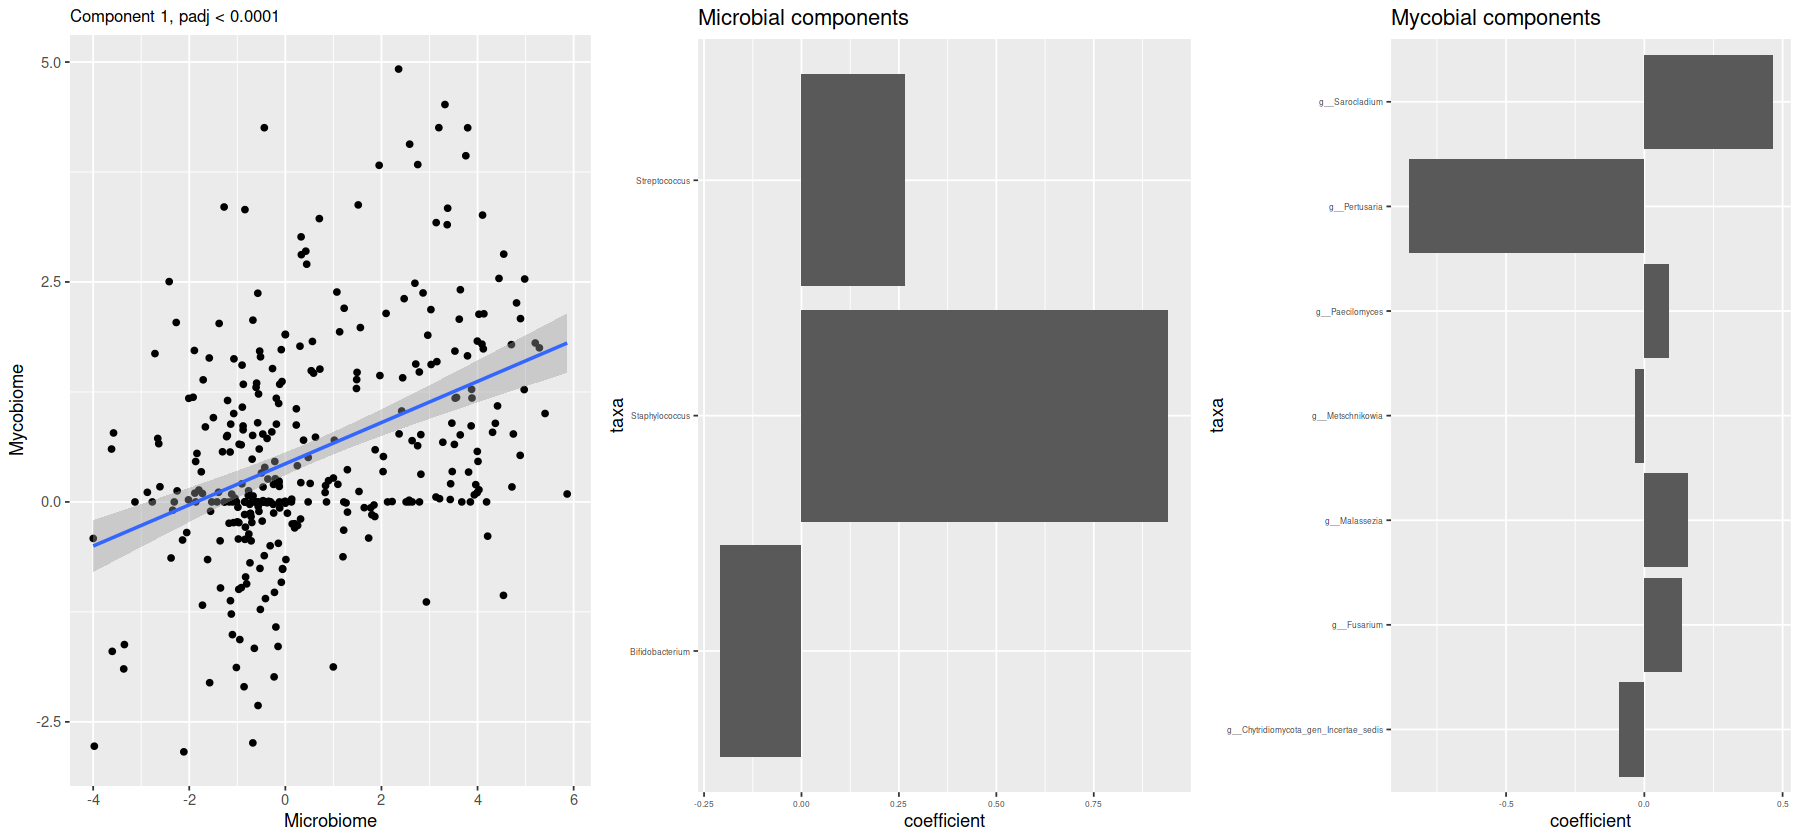

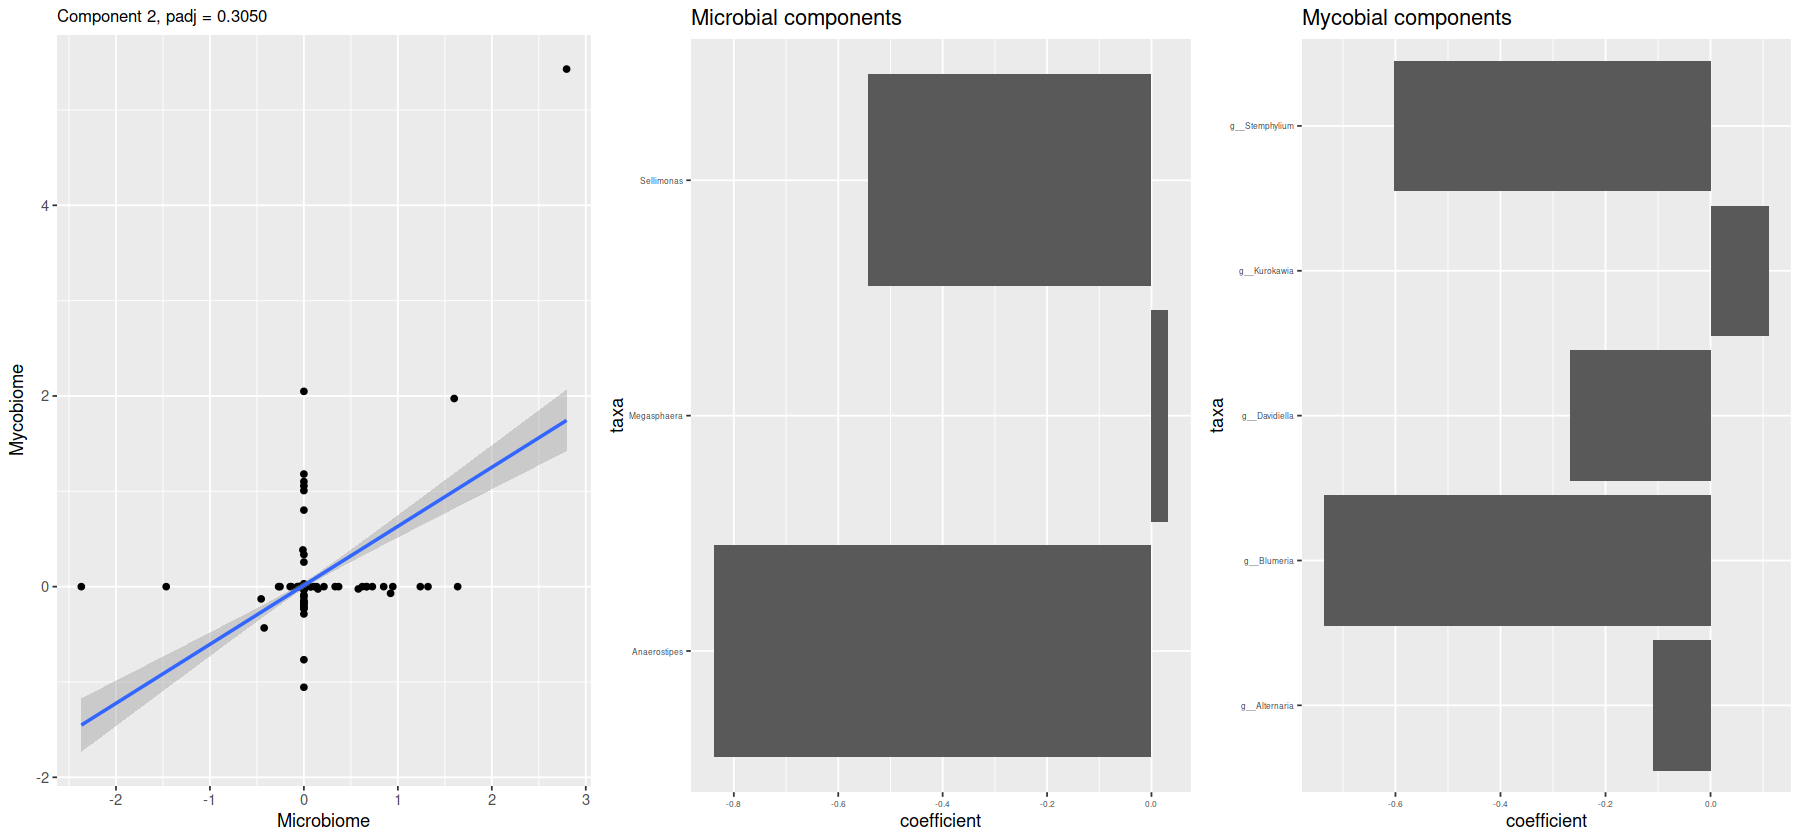

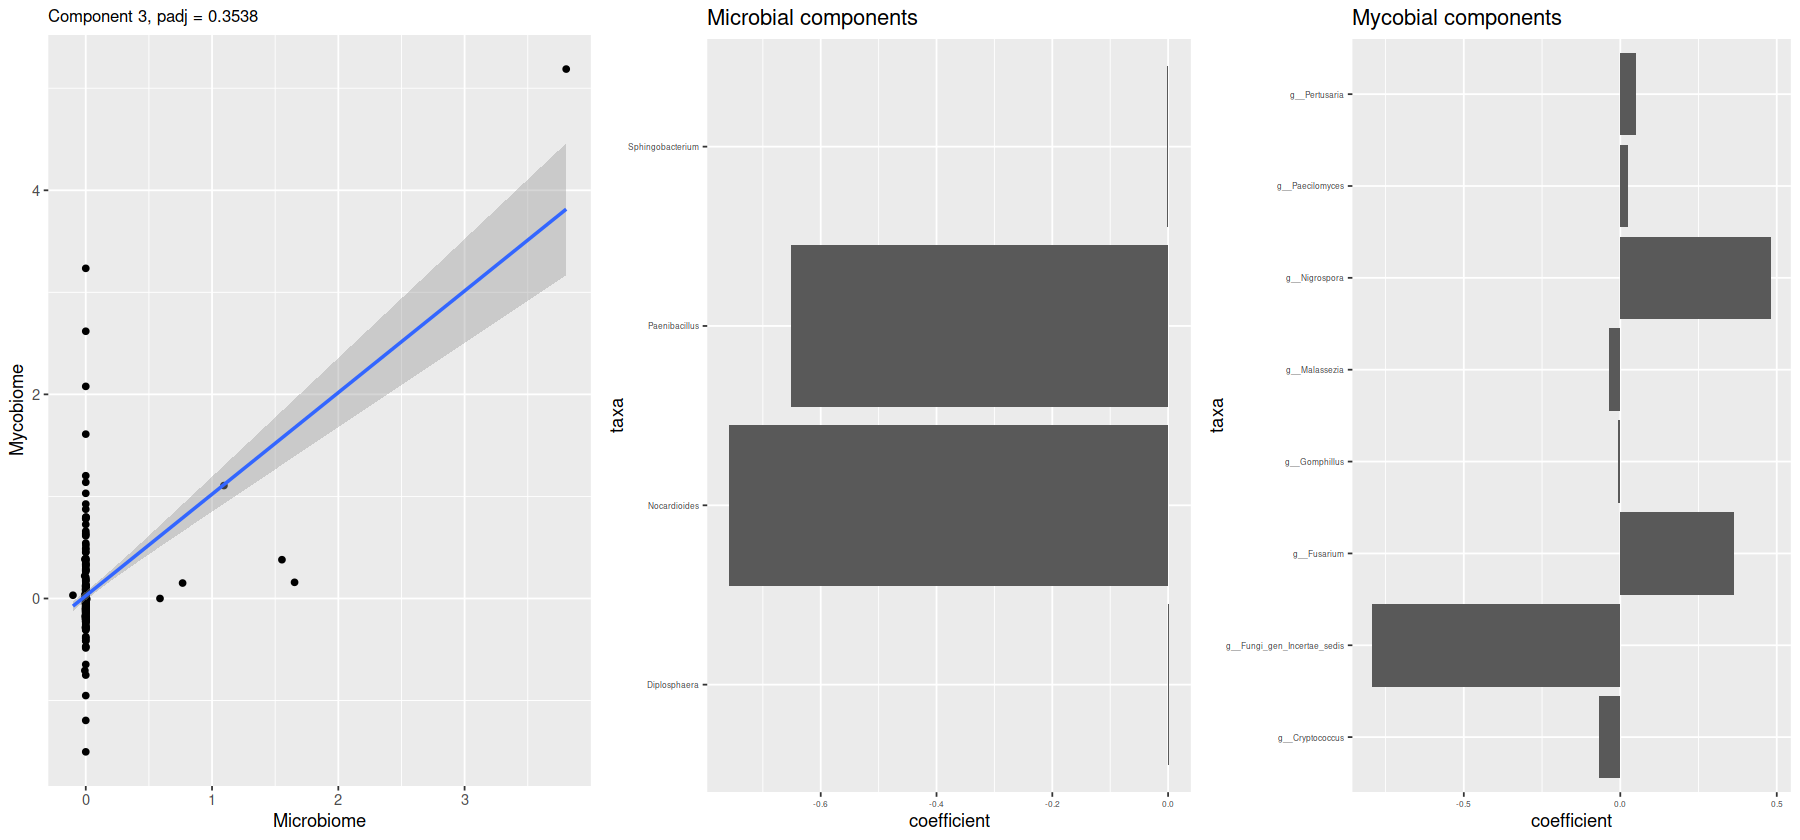

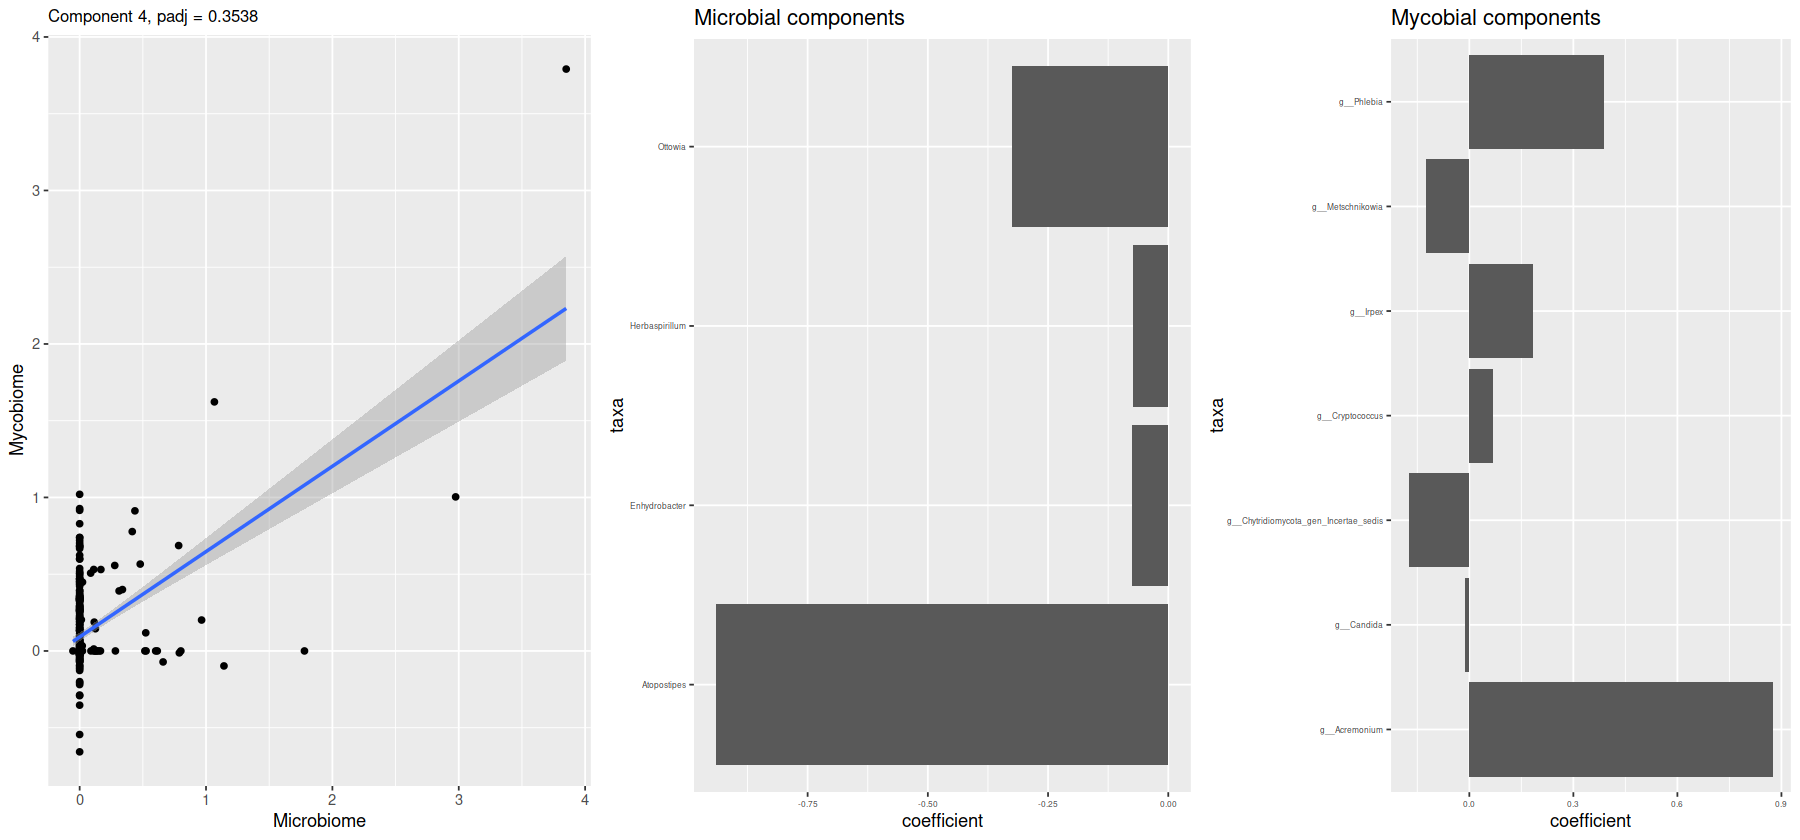

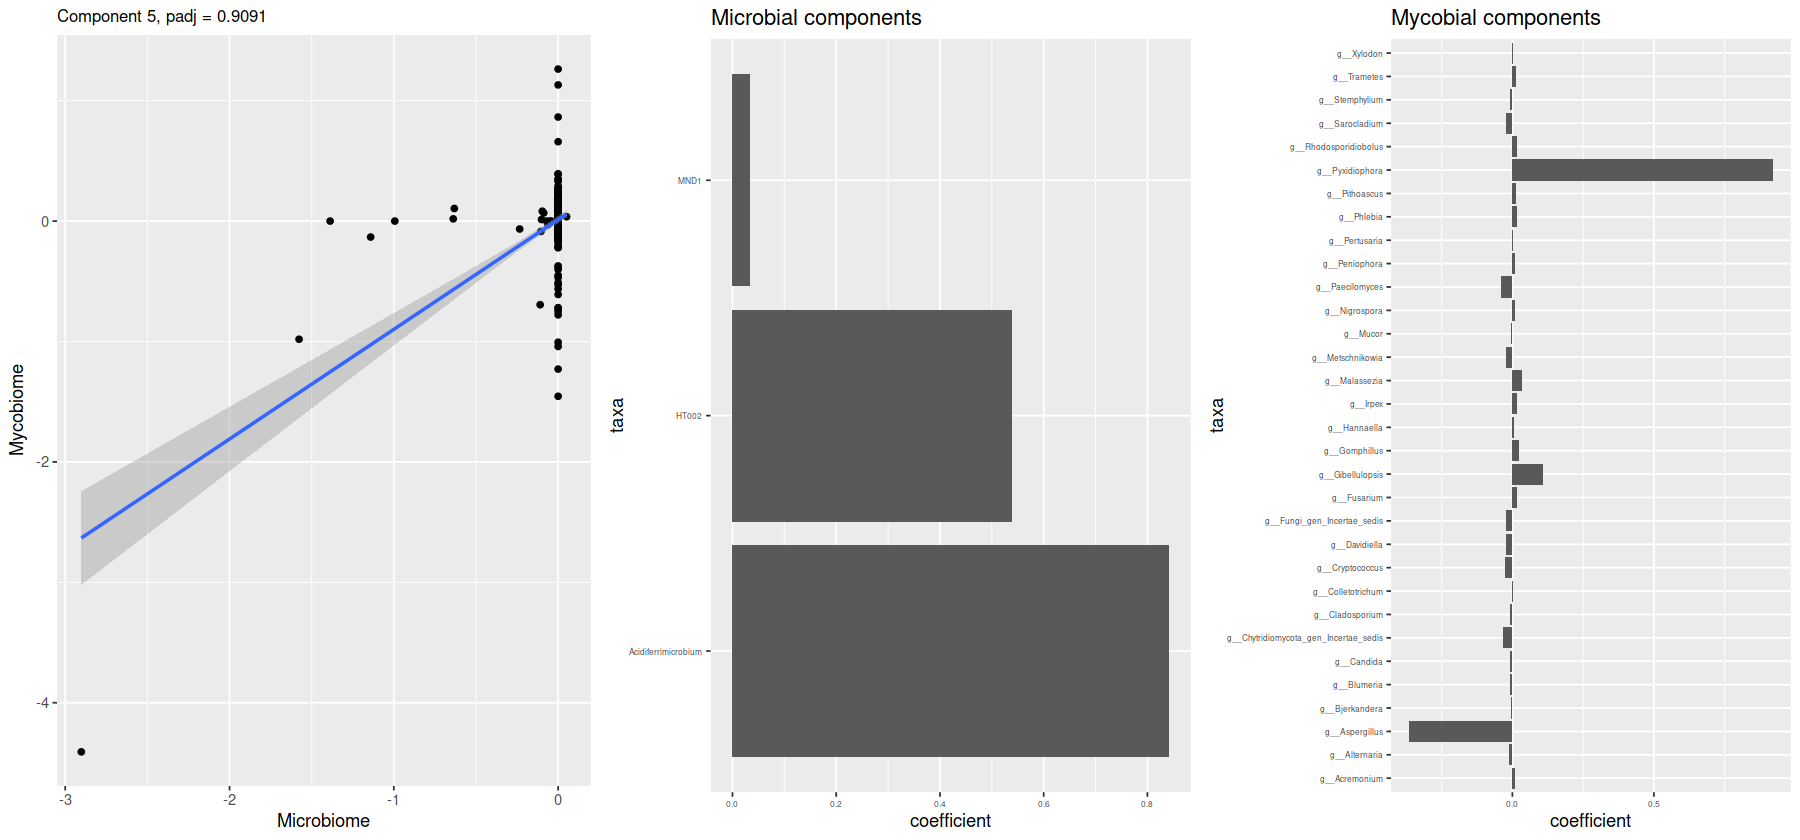

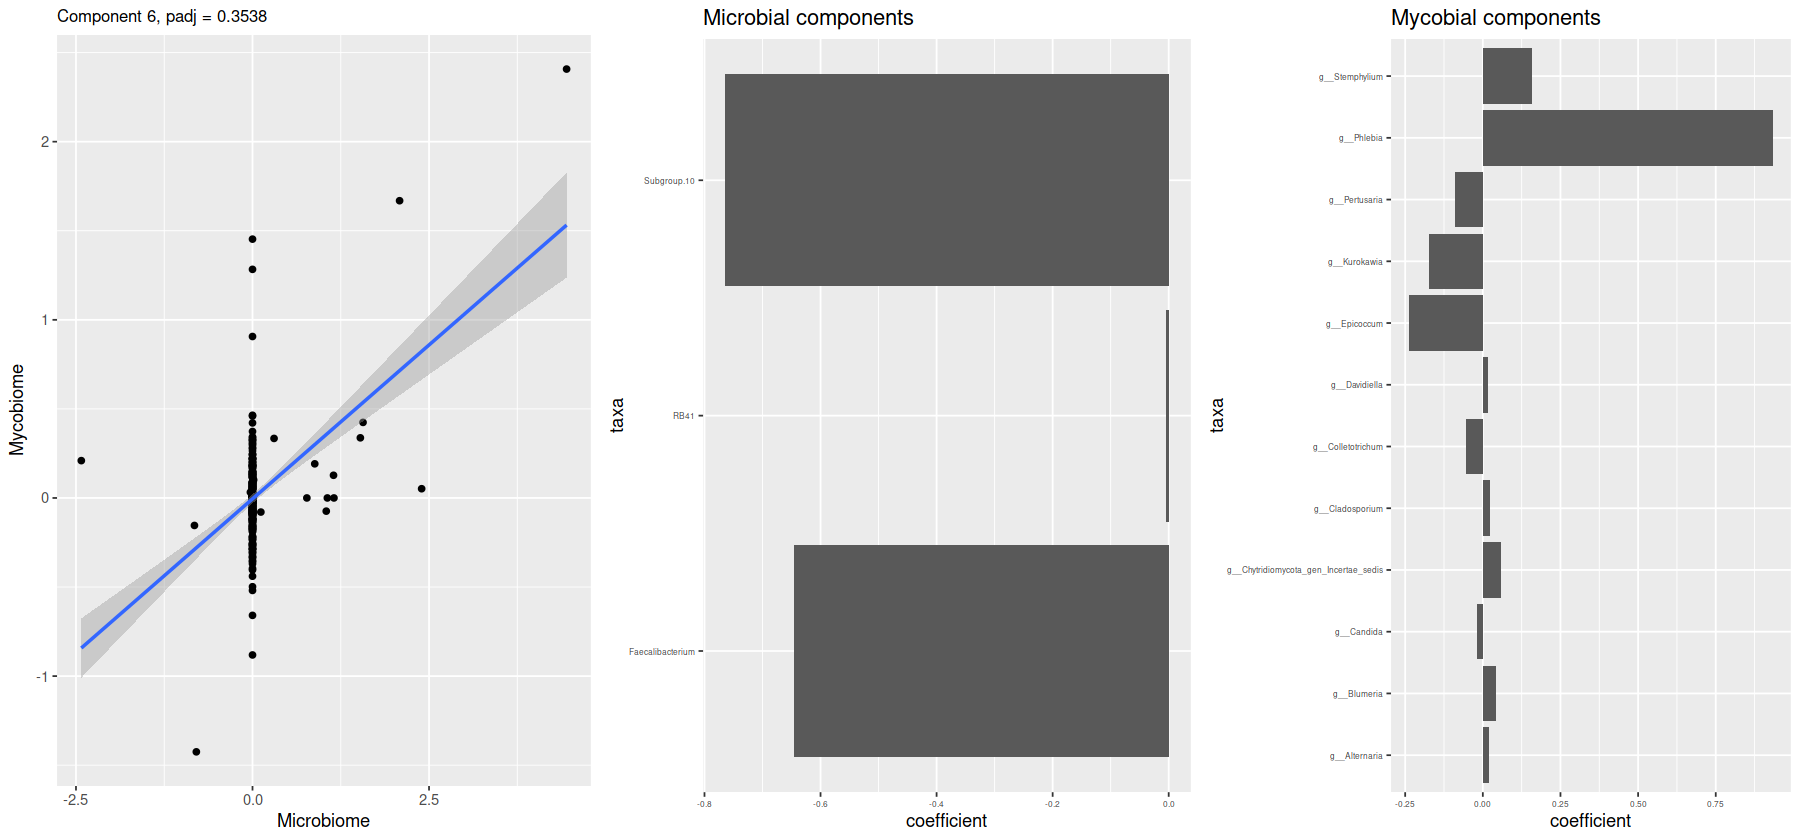

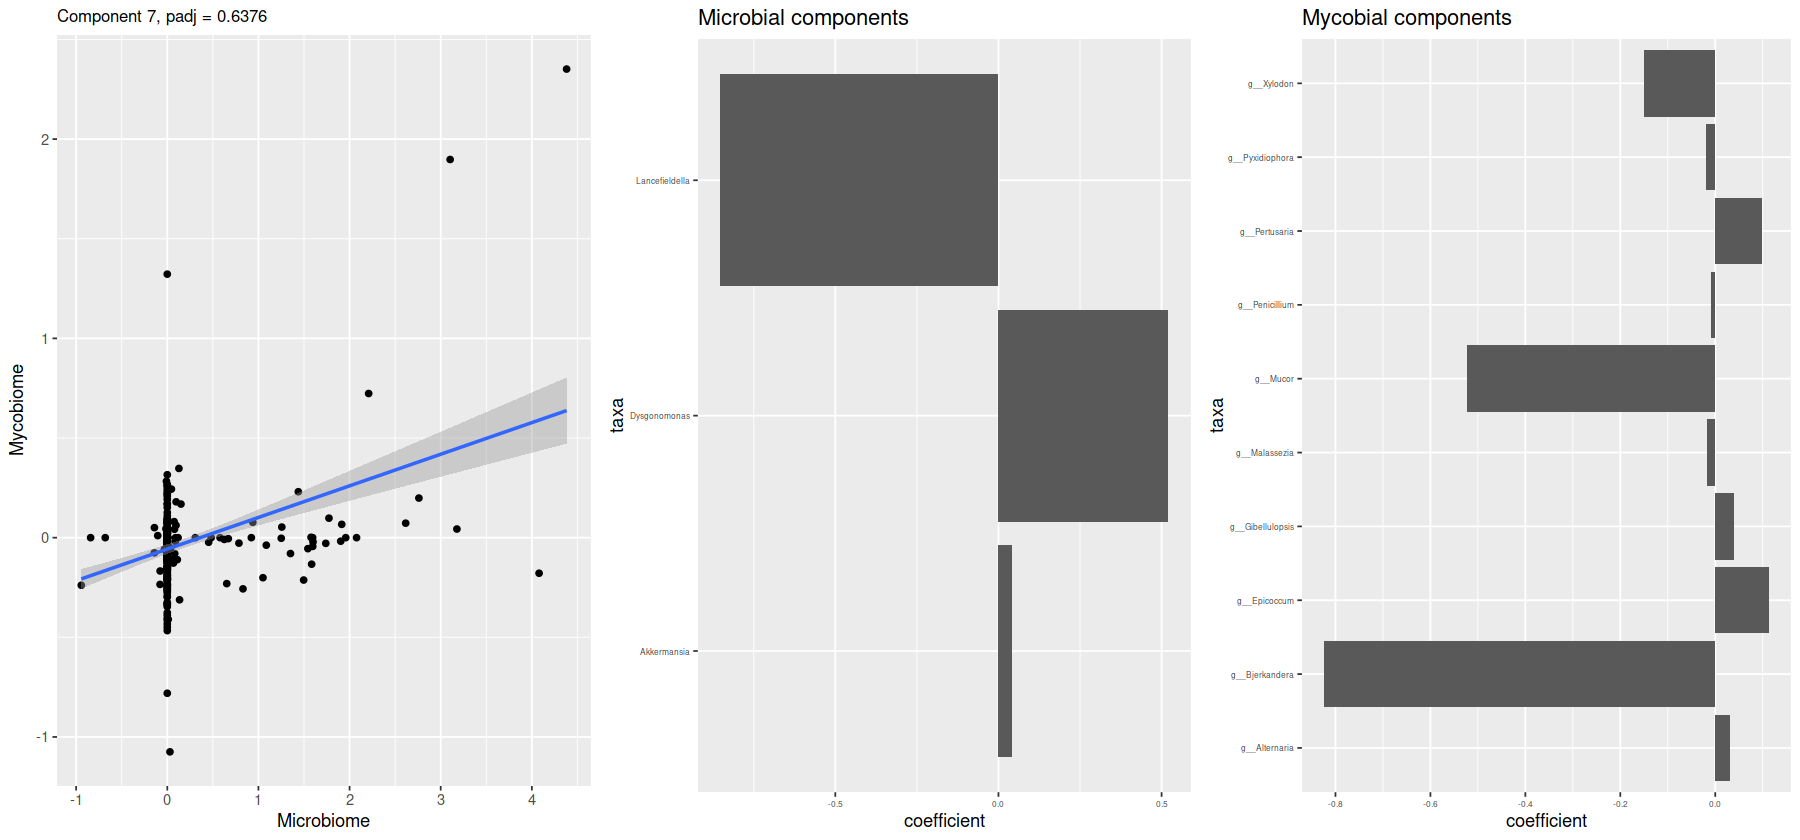

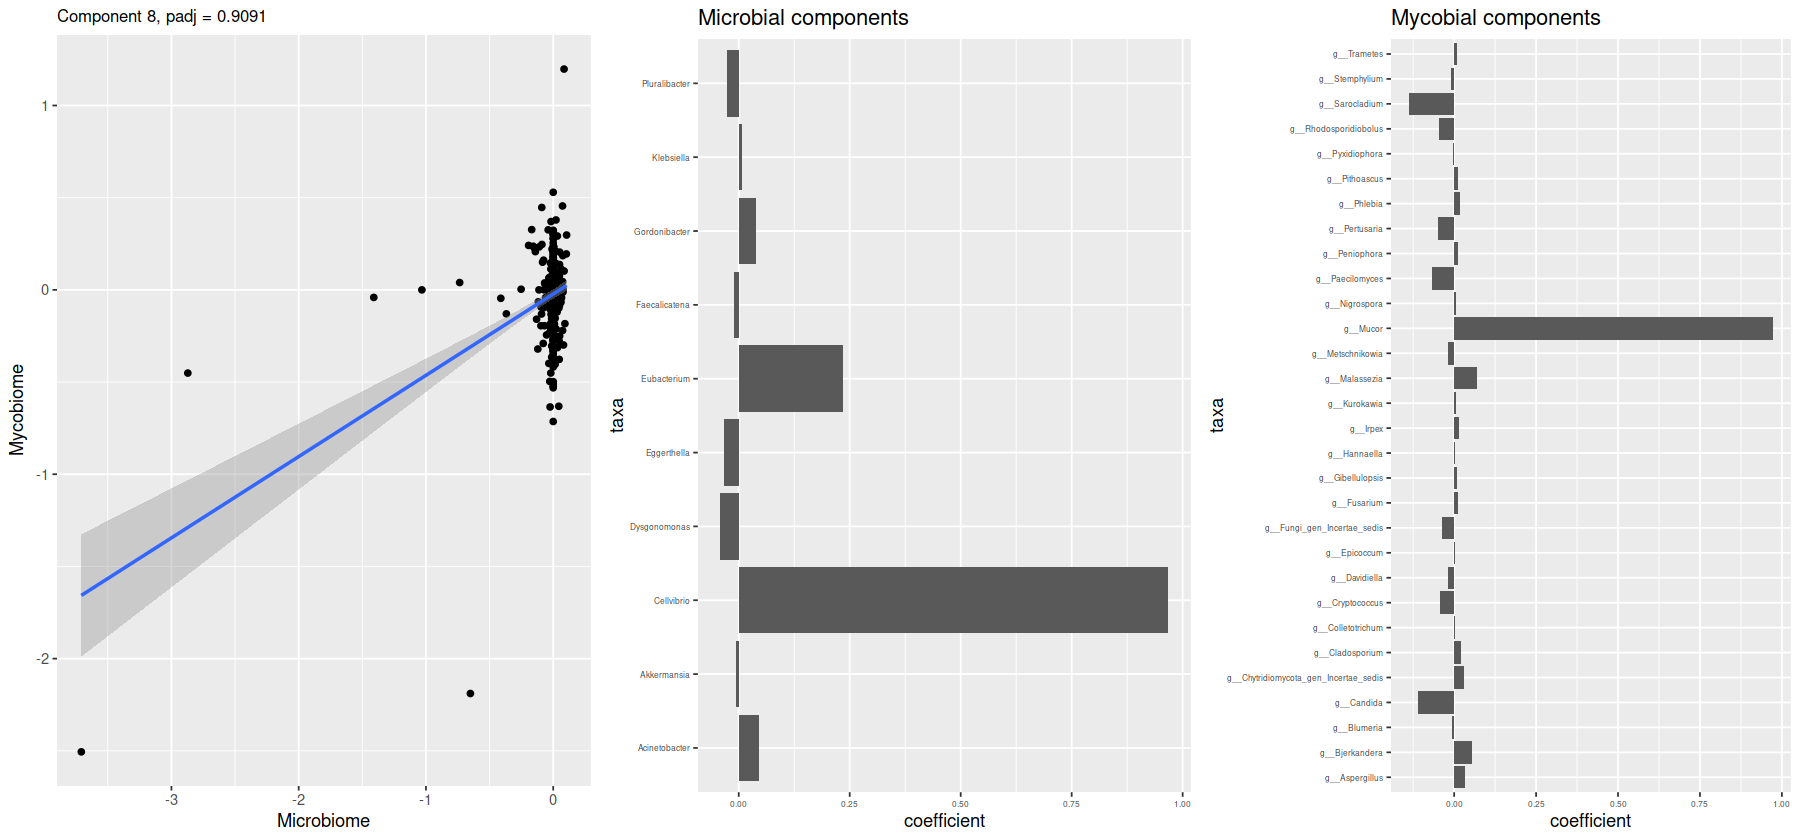

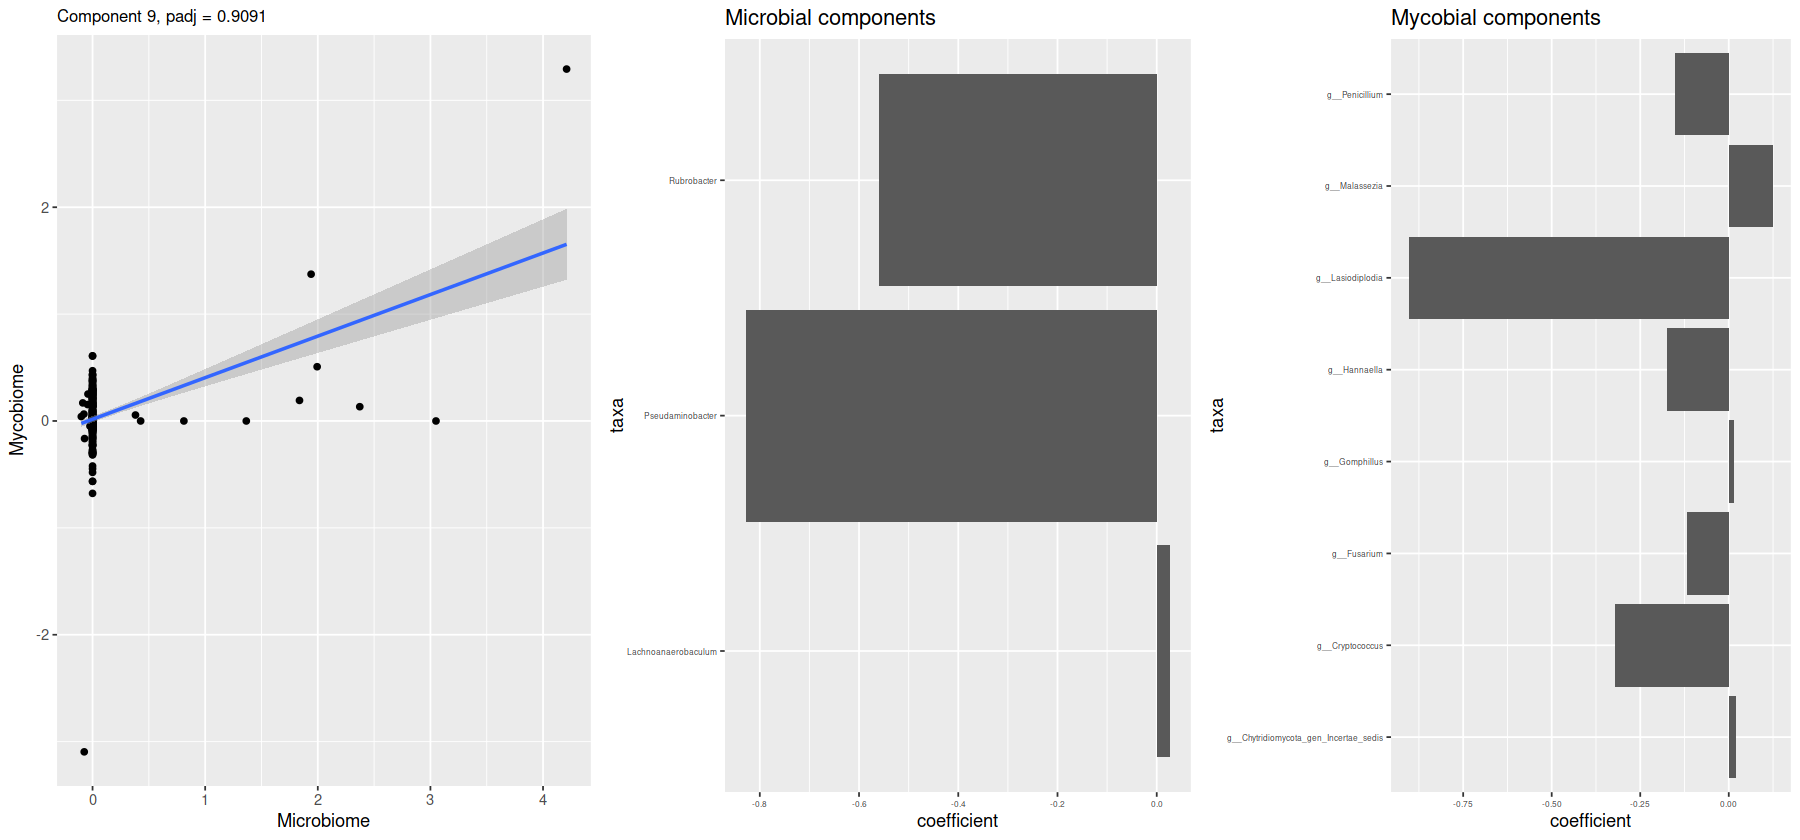

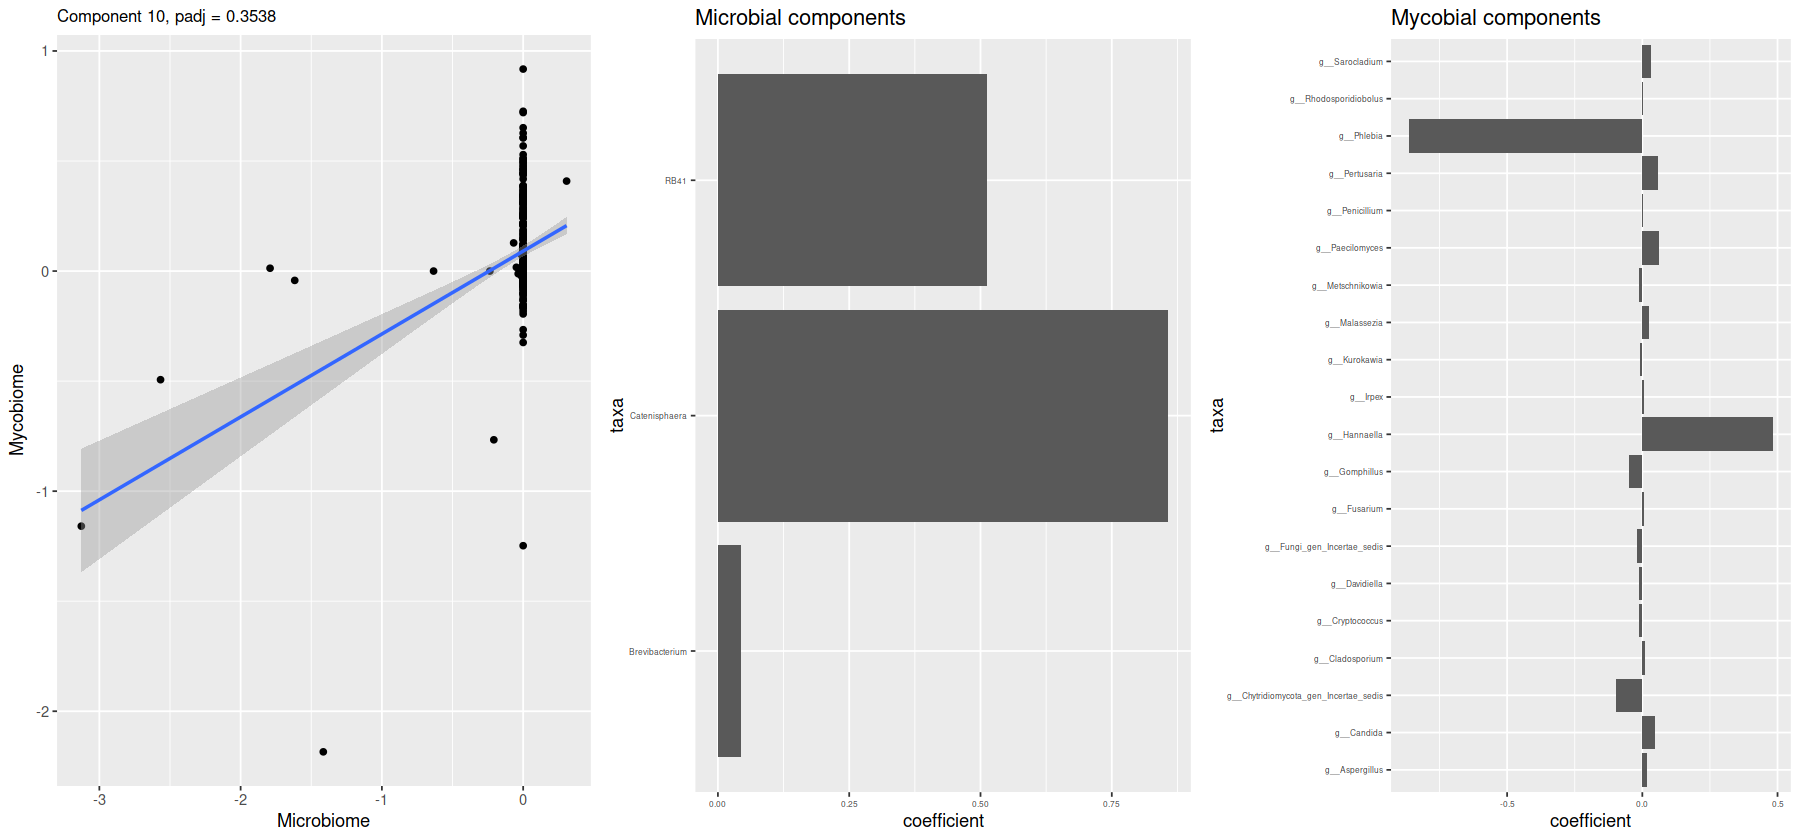

In [74]:
# Visualize each CCA component
width = 15
height = 7
options(repr.plot.width=width, repr.plot.height=height)

for (k in c(1:cca.k)){
    # Subset data for this component
    df_comp_subset <- df_comp[df_comp$component == sprintf("Comp%02d", k), ]
    coefficients_microbiome_subset <- coefficients_microbiome[
        coefficients_microbiome$component == sprintf("Comp%02d", k), ]
    coefficients_mycobiome_subset <- coefficients_mycobiome[
        coefficients_mycobiome$component == sprintf("Comp%02d", k), ]
    
    # Format p-value
    if (CCA_padj[k] < 0.0001){
        padj <- "< 0.0001"
    } else {
        padj <- sprintf("= %.4f", CCA_padj[k])
    }
    
    # Plot correlation between component scores
    plot_cca <- ggplot(df_comp_subset, aes(x = Microbiome, y = Mycobiome)) +
                  geom_point() +
                  geom_smooth(method='lm', formula= y~x) +
                  ggtitle(paste0('Component ', k, ', padj ', padj)) +
                  theme(plot.title=element_text(size=10)) 
    
    # Plot microbiome taxa loadings
    plot_microbiome <- ggplot(coefficients_microbiome_subset, 
                             aes(x = coefficient, y = taxa)) +
                       geom_bar(stat='identity') +
                       theme(axis.text=element_text(size=5)) +
                       ggtitle("Microbial components")
    
    # Plot mycobiome taxa loadings
    plot_mycobiome <- ggplot(coefficients_mycobiome_subset, 
                            aes(x = coefficient, y = taxa)) +
                      geom_bar(stat='identity')  +
                      theme(axis.text=element_text(size=5))+
                      ggtitle("Mycobial components")
    
    # Combine figures together
    p <- ggarrange(plot_cca, plot_microbiome, plot_mycobiome,
              ncol = 3, nrow = 1,
              common.legend = FALSE, legend = "bottom") 
    print(p)
}